In [1]:
import pandas as pd
import re
from difflib import get_close_matches
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import VarianceThreshold
import numpy as np
from pathlib import Path
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import chi2_contingency
from pathlib import Path
import statsmodels.api as sm
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.linear_model import RidgeCV, ElasticNetCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, f1_score,calinski_harabasz_score,davies_bouldin_score
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from joblib import Parallel, delayed
import io, base64
from scipy.stats import kruskal
from IPython.display import HTML, display
from sklearn.multioutput import MultiOutputRegressor
from sklearn.impute import SimpleImputer
from sklearn.decomposition import IncrementalPCA 
from sklearn.cluster import AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
!pip install imblearn
from sklearn.ensemble import GradientBoostingClassifier
!pip install xgboost
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from xgboost import XGBRegressor
!pip install shap
from statsmodels.stats.multitest import multipletests
from scipy.stats import t as tdist
from sklearn.svm import SVR
import shap
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, make_scorer
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import f_regression
from scipy.stats import f
from statsmodels.stats.multitest import multipletests
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import RidgeCV, MultiTaskElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from joblib import Parallel, delayed
from scipy.stats import t



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

genetic_data = pd.read_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\GeneMarkers-95 varieties 1.csv")
aroma_df= pd.read_csv(r'C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\aroma_df.csv')
sensory_pcs = pd.read_csv("sensory_pca_scores.csv")

In [3]:
def to_numeric(df):
    out = df.copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def norm_key(s):
    s = (str(s).upper().replace(".", "").replace(" ", ""))
    s = re.sub(r'\bR\b', '', s)
    s = re.sub(r'RUSSET', '', s)
    return s.split("_")[0]

# -----------------------
# Genetic data 
# -----------------------
mrk_col = "TAGLO_ID" if "TAGLO_ID" in genetic_data.columns else genetic_data.columns[0]

G = (
    genetic_data.dropna(subset=[mrk_col])
    .drop_duplicates(subset=[mrk_col])
    .set_index(mrk_col)
)

G = to_numeric(G)
gd = G.T
gd.index.name = "Variety_raw"
gd.index = gd.index.map(norm_key)

# Collapse duplicates if multiple rows per variety
gd = gd.groupby(gd.index, observed=True).mean()
gd.columns = ["GEN__" + str(c) for c in gd.columns]
print("Genetic table after reshape:", gd.shape)

# -----------------------
# Aroma data 
# -----------------------
af = aroma_df.copy()
assert "Variety" in af.columns, "aroma_df must have a 'Variety' column"
af["__key__"] = af["Variety"].map(norm_key)
af = af.set_index("__key__")

# فقط ستون‌های عددی بدون 'Variety' و 'index'
aroma_cols = [c for c in af.columns if c not in ["Variety", "index"]]

A = to_numeric(af[aroma_cols]).dropna(axis=1, how="all")
A = A.loc[:, A.std(ddof=0).fillna(0) > 0]  # drop constant cols
print(f"# aroma candidates (usable): {A.shape[1]}")
print("Sample aroma cols:", list(A.columns[:8]))

# -----------------------
# Sensory PCs 
# -----------------------
sensory_pcs = pd.read_csv("sensory_pca_projection_knn.csv")
assert "Variety" in sensory_pcs.columns, "sensory_pca_projection_knn.csv must have a 'Variety' column"

sensory_pcs["__key__"] = sensory_pcs["Variety"].map(norm_key)
sensory_pcs = sensory_pcs.set_index("__key__")

# حذف ستون‌های اضافی
S = to_numeric(sensory_pcs.drop(columns=["Variety", "is_panel"], errors="ignore"))
print(f"# sensory PCs: {S.shape[1]}")
print("Sample sensory cols:", list(S.columns[:8]))

# -----------------------
# Merge 
# -----------------------
gk = gd.copy()
gk.index.name = "Variety"

# Merge genetics with aroma 
merged_snp_aroma = gk.join(A, how="inner")
print("Merged shape (varieties × [SNPs + aroma]):", merged_snp_aroma.shape)

# Merge genetics with sensory 
merged_snp_sensory = gk.join(S, how="inner")
print("Merged shape (varieties × [SNPs + sensory PCs]):", merged_snp_sensory.shape)

# Merge genetics + aroma + sensory 
merged_all = gk.join(pd.concat([A, S], axis=1), how="inner")
print("Merged shape (varieties × [SNPs + aroma + sensory PCs]):", merged_all.shape)


Genetic table after reshape: (94, 262434)
# aroma candidates (usable): 19
Sample aroma cols: ['1-Nonanol (Floral, waxy)', '1-Octen-3-ol (Mushroom, earthy)', '2,3-Butanedione (Butter, creamy, sweet)', '2-Propanone, 1-methoxy- (Solvent, chemical)', 'Acetic acid (Vinegar, sour)', 'Benzaldehyde (Almond, cherry, fruity)', 'Butanal, 3-methyl- (Fruity, malty, chocolate)', 'Butanoic acid (Sweaty, cheesy)']
# sensory PCs: 3
Sample sensory cols: ['PC1', 'PC2', 'PC3']
Merged shape (varieties × [SNPs + aroma]): (94, 262453)
Merged shape (varieties × [SNPs + sensory PCs]): (94, 262437)
Merged shape (varieties × [SNPs + aroma + sensory PCs]): (94, 262456)


In [4]:
from sklearn.feature_selection import f_regression
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# ------------------------
# 1) GWAS روی PCها
# ------------------------
X = merged_snp_sensory[[c for c in merged_snp_sensory.columns if c.startswith("GEN__")]].fillna(0)
pcs = ["PC1", "PC2", "PC3"]

gwas_results = {}

for pc in pcs:
    print(f"\n=== GWAS for {pc} ===")
    y = merged_snp_sensory[pc].astype(float)
    
    f_vals, p_vals = f_regression(X, y)
    
    df = pd.DataFrame({
        "SNP": X.columns,
        "F_value": f_vals,
        "p_value": p_vals
    }).sort_values("p_value")
    
    gwas_results[pc] = df
    
    # ذخیره فایل
    filename = f"Top_SNPs_{pc}.csv"
    df.to_csv(filename, index=False)
    print(f"Saved results to {filename}")
    print(df.head(10))

# ------------------------
# 2) Kernel Ridge روی Top SNPs
# ------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1]
}

results = []
for trait in pcs:
    print(f"\n=== Kernel Ridge for {trait} ===")
    
    # انتخاب Top 500 SNP از GWAS
    top_snps = gwas_results[trait]["SNP"].head(500).tolist()
    X_top = merged_snp_sensory[top_snps].fillna(0).astype(float)
    y = merged_snp_sensory[trait].astype(float)
    
    # Scale
    X_scaled = StandardScaler().fit_transform(X_top)
    
    # GridSearchCV روی Kernel Ridge
    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid=param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_scaled, y)
    
    results.append({
        "Trait": trait,
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_R2_mean": grid.best_score_
    })

# نتایج نهایی
results_df_sensory = pd.DataFrame(results)
print("\n=== Final Results (Kernel Ridge tuned, Top 500 SNPs) ===")
print(results_df_sensory)

# ذخیره نتایج
results_df_sensory.to_csv("KernelRidge_SensoryPCs_results.csv", index=False)



=== GWAS for PC1 ===
Saved results to Top_SNPs_PC1.csv
               SNP    F_value       p_value
74632  GEN__159491  31.247696  2.304461e-07
74658  GEN__159526  31.247696  2.304461e-07
75073  GEN__160143  31.247696  2.304461e-07
74868  GEN__159825  31.247696  2.304461e-07
74844  GEN__159790  31.247696  2.304461e-07
74690  GEN__159573  31.247696  2.304461e-07
74897  GEN__159869  31.247696  2.304461e-07
74688  GEN__159571  31.247696  2.304461e-07
74816  GEN__159753  31.247696  2.304461e-07
75235  GEN__160414  31.247696  2.304461e-07

=== GWAS for PC2 ===
Saved results to Top_SNPs_PC2.csv
                SNP    F_value   p_value
59321   GEN__121113  23.632795  0.000005
50531   GEN__105134  19.569220  0.000027
101533  GEN__216895  18.847951  0.000036
71550   GEN__154453  18.083603  0.000051
71497   GEN__154367  18.083603  0.000051
71467   GEN__154319  18.083603  0.000051
71496   GEN__154366  18.083603  0.000051
69069   GEN__150170  18.083603  0.000051
71445   GEN__154281  18.083603  0.0

C:\Users\fatemehm\AppData\Local\Temp\ipykernel_1816\1956809001.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df_sensory, x="Trait", y="CV_R2_mean", palette="viridis")


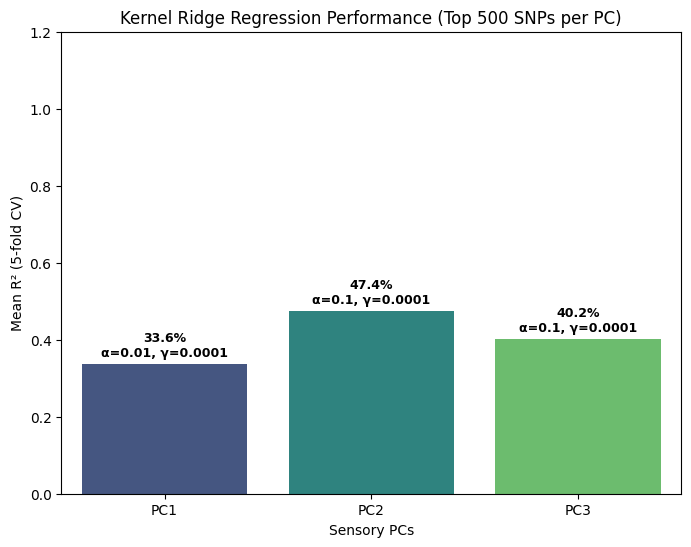

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(data=results_df_sensory, x="Trait", y="CV_R2_mean", palette="viridis")

# نوشتن درصد + پارامترهای بهترین مدل
for i, row in results_df_sensory.iterrows():
    percent = row["CV_R2_mean"] * 100
    alpha = row["Best_alpha"]
    gamma = row["Best_gamma"]
    plt.text(i, row["CV_R2_mean"] + 0.02,
             f"{percent:.1f}%\nα={alpha}, γ={gamma}", 
             ha="center", fontsize=9, fontweight="bold", color="black")

plt.title("Kernel Ridge Regression Performance (Top 500 SNPs per PC)")
plt.ylabel("Mean R² (5-fold CV)")
plt.xlabel("Sensory PCs")
plt.ylim(0, 1.2)  # کمی جا بیشتر برای متن
plt.show()


In [6]:
from sklearn.feature_selection import f_regression
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# =====================================================
# LD pruning function (pairwise correlation-based)
# =====================================================
def ld_prune(df, threshold=0.95):
    """
    Remove SNPs with pairwise correlation above threshold.
    Keeps the first SNP and removes correlated ones.
    """
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop)

# =====================================================
# 1) GWAS on PCs
# =====================================================
X = merged_snp_sensory[[c for c in merged_snp_sensory.columns if c.startswith("GEN__")]].fillna(0)
pcs = ["PC1", "PC2", "PC3"]

gwas_results = {}
for pc in pcs:
    print(f"\n=== GWAS for {pc} ===")
    y = merged_snp_sensory[pc].astype(float)

    f_vals, p_vals = f_regression(X, y)

    df = pd.DataFrame({
        "SNP": X.columns,
        "F_value": f_vals,
        "p_value": p_vals
    }).sort_values("p_value")

    gwas_results[pc] = df

    # Save file
    filename = f"Top_SNPs_{pc}.csv"
    df.to_csv(filename, index=False)
    print(f"Saved results to {filename}")
    print(df.head(10))

# =====================================================
# 2) Kernel Ridge on Top SNPs + LD pruning
# =====================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1]
}

results = []
for trait in pcs:
    print(f"\n=== Kernel Ridge for {trait} ===")

    # Select top 500 SNPs
    top_snps = gwas_results[trait]["SNP"].head(700).tolist()
    X_top = merged_snp_sensory[top_snps].fillna(0).astype(float)

    # LD pruning
    X_pruned = ld_prune(X_top, threshold=0.95)
    print(f"Trait {trait}: {X_top.shape[1]} SNPs → {X_pruned.shape[1]} after LD pruning")

    if X_pruned.shape[1] == 0:
        continue

    y = merged_snp_sensory[trait].astype(float)

    # Scale
    X_scaled = StandardScaler().fit_transform(X_pruned)

    # GridSearchCV with Kernel Ridge
    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid=param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_scaled, y)

    results.append({
        "Trait": trait,
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_R2_mean": grid.best_score_,
        "N_SNPs_used": X_pruned.shape[1]
    })

# Final results
results_df_sensory = pd.DataFrame(results)
print("\n=== Final Results (Kernel Ridge tuned, Top 500 SNPs, LD pruned) ===")
print(results_df_sensory)

# Save results
results_df_sensory.to_csv("KernelRidge_SensoryPCs_results_LDpruned.csv", index=False)



=== GWAS for PC1 ===
Saved results to Top_SNPs_PC1.csv
               SNP    F_value       p_value
74632  GEN__159491  31.247696  2.304461e-07
74658  GEN__159526  31.247696  2.304461e-07
75073  GEN__160143  31.247696  2.304461e-07
74868  GEN__159825  31.247696  2.304461e-07
74844  GEN__159790  31.247696  2.304461e-07
74690  GEN__159573  31.247696  2.304461e-07
74897  GEN__159869  31.247696  2.304461e-07
74688  GEN__159571  31.247696  2.304461e-07
74816  GEN__159753  31.247696  2.304461e-07
75235  GEN__160414  31.247696  2.304461e-07

=== GWAS for PC2 ===
Saved results to Top_SNPs_PC2.csv
                SNP    F_value   p_value
59321   GEN__121113  23.632795  0.000005
50531   GEN__105134  19.569220  0.000027
101533  GEN__216895  18.847951  0.000036
71550   GEN__154453  18.083603  0.000051
71497   GEN__154367  18.083603  0.000051
71467   GEN__154319  18.083603  0.000051
71496   GEN__154366  18.083603  0.000051
69069   GEN__150170  18.083603  0.000051
71445   GEN__154281  18.083603  0.0

# using LD_pruning

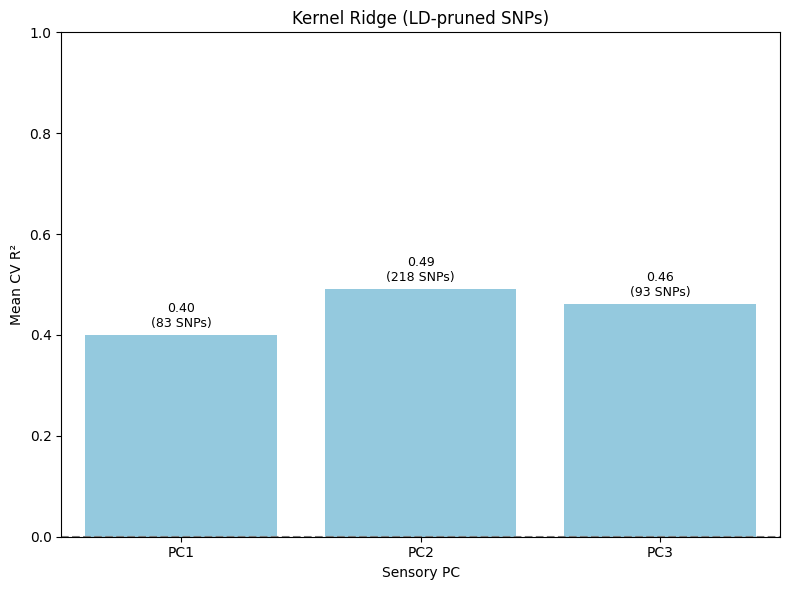

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    data=results_df_sensory,
    x="Trait", y="CV_R2_mean", color="skyblue"
)

# Annotate values on top of bars
for i, row in results_df_sensory.iterrows():
    plt.text(i, row["CV_R2_mean"] + 0.01,
             f"{row['CV_R2_mean']:.2f}\n({row['N_SNPs_used']} SNPs)",
             ha="center", va="bottom", fontsize=9)

plt.axhline(0, color="gray", linestyle="--")
plt.ylabel("Mean CV R²")
plt.xlabel("Sensory PC")
plt.title("Kernel Ridge (LD-pruned SNPs)")
plt.ylim(0, 1)   # adjust if needed
plt.tight_layout()
plt.show()


In [8]:
from sklearn.preprocessing import StandardScaler

# =====================================================
# 2) Kernel Ridge on Top SNPs + LD pruning (with y-scaling)
# =====================================================
kf = KFold(n_splits=3, shuffle=True, random_state=42)
param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1]
}

results = []
for trait in pcs:
    print(f"\n=== Kernel Ridge for {trait} ===")

    # Select top 500 SNPs
    top_snps = gwas_results[trait]["SNP"].head(700).tolist()
    X_top = merged_snp_sensory[top_snps].fillna(0).astype(float)

    # LD pruning
    X_pruned = ld_prune(X_top, threshold=0.9)
    print(f"Trait {trait}: {X_top.shape[1]} SNPs → {X_pruned.shape[1]} after LD pruning")

    if X_pruned.shape[1] == 0:
        continue

    y = merged_snp_sensory[trait].astype(float).values.reshape(-1, 1)

    # Scale X
    X_scaled = StandardScaler().fit_transform(X_pruned)

    # Scale y
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y).ravel()  # flatten back to 1D

    # GridSearchCV with Kernel Ridge
    grid = GridSearchCV(
        KernelRidge(kernel="rbf"),
        param_grid=param_grid,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_scaled, y_scaled)

    results.append({
        "Trait": trait,
        "Best_alpha": grid.best_params_["alpha"],
        "Best_gamma": grid.best_params_["gamma"],
        "CV_R2_mean": grid.best_score_,
        "N_SNPs_used": X_pruned.shape[1]
    })

# Final results
results_df_sensory = pd.DataFrame(results)
print("\n=== Final Results (Kernel Ridge tuned, Top 500 SNPs, LD pruned, y-scaled) ===")
print(results_df_sensory)

# Save results
results_df_sensory.to_csv("KernelRidge_SensoryPCs_results_LDpruned_yScaled.csv", index=False)



=== Kernel Ridge for PC1 ===
Trait PC1: 700 SNPs → 55 after LD pruning

=== Kernel Ridge for PC2 ===
Trait PC2: 700 SNPs → 185 after LD pruning

=== Kernel Ridge for PC3 ===
Trait PC3: 700 SNPs → 76 after LD pruning

=== Final Results (Kernel Ridge tuned, Top 500 SNPs, LD pruned, y-scaled) ===
  Trait  Best_alpha  Best_gamma  CV_R2_mean  N_SNPs_used
0   PC1        0.01      0.0001    0.485544           55
1   PC2        0.01      0.0001    0.558367          185
2   PC3        0.01      0.0001    0.523212           76


# other model after ld pruning

In [9]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor

# Define models and parameter grids
models = {
    "KernelRidge": (
        KernelRidge(kernel="rbf"),
        {"alpha": [0.001, 0.01, 0.1, 1, 10],
         "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1]}
    ),
    "Ridge": (
        Ridge(),
        {"alpha": [0.01, 0.1, 1, 10, 100]}
    ),
    "Lasso": (
        Lasso(max_iter=5000),
        {"alpha": [0.001, 0.01, 0.1, 1, 10]}
    ),
    "ElasticNet": (
        ElasticNet(max_iter=5000),
        {"alpha": [0.001, 0.01, 0.1, 1, 10],
         "l1_ratio": [0.1, 0.5, 0.9]}
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {"n_estimators": [100, 200],
         "max_depth": [None, 10, 20]}
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {"n_estimators": [100, 200],
         "learning_rate": [0.01, 0.1]}
    ),
    "SVR": (
        SVR(kernel="rbf"),
        {"C": [0.1, 1, 10],
         "gamma": ["scale", "auto"]}
    ),
    "Dummy": (
        DummyRegressor(strategy="mean"),
        {}
    )
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)

results = []
for trait in pcs:
    print(f"\n=== Modeling {trait} ===")

    # Select top SNPs
    top_snps = gwas_results[trait]["SNP"].head(1500).tolist()
    X_top = merged_snp_sensory[top_snps].fillna(0).astype(float)

    # LD pruning
    X_pruned = ld_prune(X_top, threshold=0.9)
    print(f"Trait {trait}: {X_top.shape[1]} SNPs → {X_pruned.shape[1]} after LD pruning")

    if X_pruned.shape[1] == 0:
        continue

    y = merged_snp_sensory[trait].astype(float).values.reshape(-1, 1)

    # Scale X
    X_scaled = StandardScaler().fit_transform(X_pruned)

    # Scale y
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y).ravel()

    for model_name, (model, param_grid) in models.items():
        print(f"\n--- {model_name} ---")
        grid = GridSearchCV(
            model,
            param_grid=param_grid,
            cv=kf,
            scoring="r2",
            n_jobs=-1
        )
        grid.fit(X_scaled, y_scaled)

        results.append({
            "Trait": trait,
            "Model": model_name,
            "Best_Params": grid.best_params_,
            "CV_R2_mean": grid.best_score_,
            "N_SNPs_used": X_pruned.shape[1]
        })

# Final results
results_df_sensory = pd.DataFrame(results)
print("\n=== Final Results (All Models) ===")
print(results_df_sensory)

# Save
results_df_sensory.to_csv("SensoryPCs_AllModels_results.csv", index=False)



=== Modeling PC1 ===
Trait PC1: 1500 SNPs → 140 after LD pruning

--- KernelRidge ---

--- Ridge ---

--- Lasso ---

--- ElasticNet ---

--- RandomForest ---

--- GradientBoosting ---

--- SVR ---

--- Dummy ---

=== Modeling PC2 ===
Trait PC2: 1500 SNPs → 187 after LD pruning

--- KernelRidge ---

--- Ridge ---

--- Lasso ---

--- ElasticNet ---

--- RandomForest ---

--- GradientBoosting ---

--- SVR ---

--- Dummy ---

=== Modeling PC3 ===
Trait PC3: 1500 SNPs → 207 after LD pruning

--- KernelRidge ---

--- Ridge ---

--- Lasso ---

--- ElasticNet ---

--- RandomForest ---

--- GradientBoosting ---

--- SVR ---

--- Dummy ---

=== Final Results (All Models) ===
   Trait             Model                                   Best_Params  \
0    PC1       KernelRidge              {'alpha': 0.01, 'gamma': 0.0001}   
1    PC1             Ridge                                {'alpha': 100}   
2    PC1             Lasso                                {'alpha': 0.1}   
3    PC1        Elast

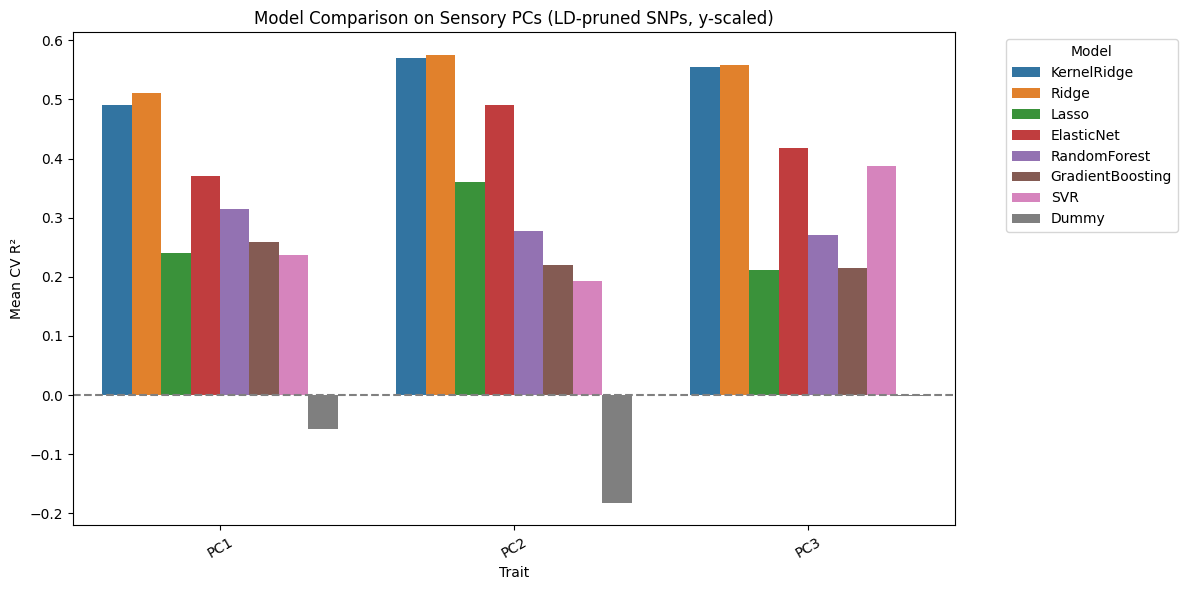


=== Final SNPs after LD pruning per trait ===
  Trait  N_SNPs_used
0   PC1          140
1   PC2          187
2   PC3          207


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot grouped bar chart (Trait × Model)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_sensory,
    x="Trait",
    y="CV_R2_mean",
    hue="Model",
    palette="tab10"
)

plt.axhline(0, color="gray", linestyle="--")
plt.title("Model Comparison on Sensory PCs (LD-pruned SNPs, y-scaled)")
plt.ylabel("Mean CV R²")
plt.xlabel("Trait")

# Rotate x-labels if traits overlap
plt.xticks(rotation=30)

# Move legend outside
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()
# Extract unique traits and SNP counts
snp_counts = results_df_sensory.groupby("Trait")["N_SNPs_used"].first().reset_index()

print("\n=== Final SNPs after LD pruning per trait ===")
print(snp_counts)

# If you want to save it:
snp_counts.to_csv("Final_SNPs_after_LDpruning.csv", index=False)


# the best with wider range

In [11]:
from sklearn.kernel_ridge import KernelRidge
import numpy as np

# Define models and parameter grids (expanded for Ridge & KRR)
models = {
    "KernelRidge": (
        KernelRidge(),
        {
            "kernel": ["rbf", "poly", "laplacian"],
            "alpha": np.logspace(-4, 2, 10),   # 1e-4 → 1e2
            "gamma": np.logspace(-5, 1, 10),   # 1e-5 → 10
            "degree": [2, 3]                   # only used for poly kernel
        }
    ),
    "Ridge": (
        Ridge(),
        {"alpha": np.logspace(-4, 4, 20)}      # finer grid, 1e-4 → 1e4
    )
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)

results = []
for trait in pcs:
    print(f"\n=== Modeling {trait} ===")

    # Select top SNPs (expanded from 1500 to test wider space)
    top_snps = gwas_results[trait]["SNP"].head(1500).tolist()
    X_top = merged_snp_sensory[top_snps].fillna(0).astype(float)

    # LD pruning
    X_pruned = ld_prune(X_top, threshold=0.9)
    print(f"Trait {trait}: {X_top.shape[1]} SNPs → {X_pruned.shape[1]} after LD pruning")

    if X_pruned.shape[1] == 0:
        continue

    y = merged_snp_sensory[trait].astype(float).values.reshape(-1, 1)

    # Scale X
    X_scaled = StandardScaler().fit_transform(X_pruned)

    # Scale y
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y).ravel()

    for model_name, (model, param_grid) in models.items():
        print(f"\n--- {model_name} ---")
        grid = GridSearchCV(
            model,
            param_grid=param_grid,
            cv=kf,
            scoring="r2",
            n_jobs=-1
        )
        grid.fit(X_scaled, y_scaled)

        results.append({
            "Trait": trait,
            "Model": model_name,
            "Best_Params": grid.best_params_,
            "CV_R2_mean": grid.best_score_,
            "N_SNPs_used": X_pruned.shape[1]
        })

# Final results
results_df_sensory = pd.DataFrame(results)
print("\n=== Final Results (Ridge & Kernel Ridge, Expanded Search) ===")
print(results_df_sensory)

# Save
results_df_sensory.to_csv("SensoryPCs_Ridge_KRR_Expanded_results.csv", index=False)



=== Modeling PC1 ===
Trait PC1: 1500 SNPs → 140 after LD pruning

--- KernelRidge ---

--- Ridge ---

=== Modeling PC2 ===
Trait PC2: 1500 SNPs → 187 after LD pruning

--- KernelRidge ---

--- Ridge ---

=== Modeling PC3 ===
Trait PC3: 1500 SNPs → 207 after LD pruning

--- KernelRidge ---

--- Ridge ---

=== Final Results (Ridge & Kernel Ridge, Expanded Search) ===
  Trait        Model                                        Best_Params  \
0   PC1  KernelRidge  {'alpha': 0.21544346900318823, 'degree': 2, 'g...   
1   PC1        Ridge                       {'alpha': 78.47599703514607}   
2   PC2  KernelRidge  {'alpha': 0.00046415888336127773, 'degree': 2,...   
3   PC2        Ridge                       {'alpha': 78.47599703514607}   
4   PC3  KernelRidge  {'alpha': 0.01, 'degree': 3, 'gamma': 1e-05, '...   
5   PC3        Ridge                        {'alpha': 206.913808111479}   

   CV_R2_mean  N_SNPs_used  
0    0.513576          140  
1    0.508951          140  
2    0.576288     

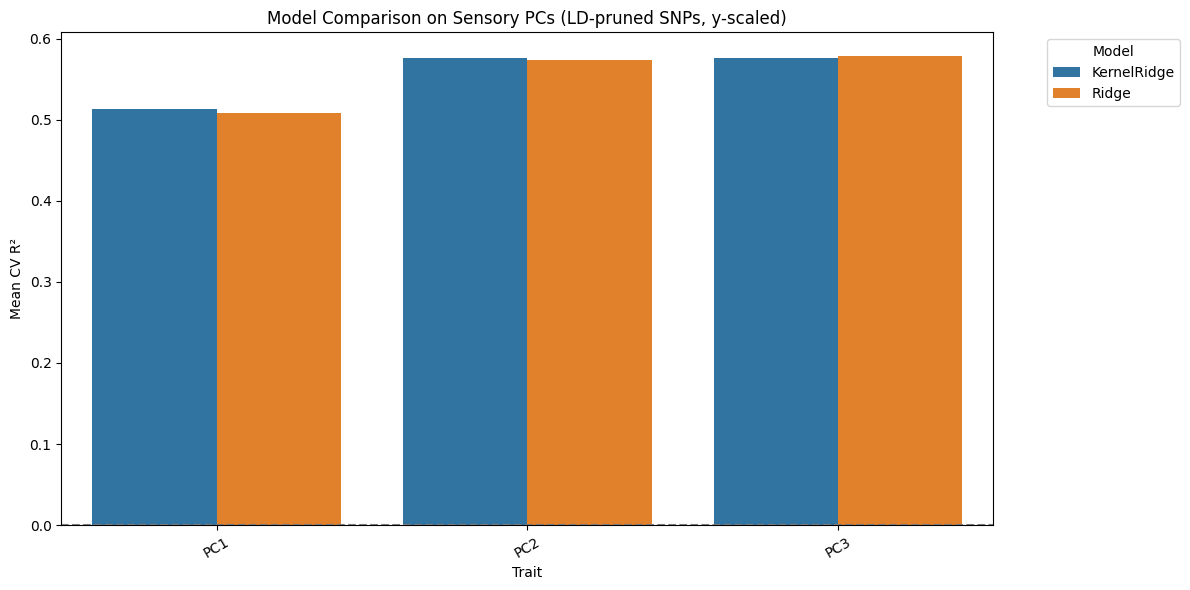


=== Final SNPs after LD pruning per trait ===
  Trait  N_SNPs_used
0   PC1          140
1   PC2          187
2   PC3          207


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot grouped bar chart (Trait × Model)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_df_sensory,
    x="Trait",
    y="CV_R2_mean",
    hue="Model",
    palette="tab10"
)

plt.axhline(0, color="gray", linestyle="--")
plt.title("Model Comparison on Sensory PCs (LD-pruned SNPs, y-scaled)")
plt.ylabel("Mean CV R²")
plt.xlabel("Trait")

# Rotate x-labels if traits overlap
plt.xticks(rotation=30)

# Move legend outside
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()
# Extract unique traits and SNP counts
snp_counts = results_df_sensory.groupby("Trait")["N_SNPs_used"].first().reset_index()

print("\n=== Final SNPs after LD pruning per trait ===")
print(snp_counts)

# If you want to save it:
snp_counts.to_csv("Final_SNPs_after_LDpruning.csv", index=False)


# # Stacked(ridge/krr)

In [13]:
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
import pandas as pd
import numpy as np

kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Define models and parameter grids
models = {
    "KernelRidge": (
        KernelRidge(kernel="rbf"),
        {"alpha": [0.001, 0.01, 0.1, 1, 10],
         "gamma": [1e-4, 1e-3, 1e-2, 0.1, 1]}
    ),
    "Ridge": (
        Ridge(),
        {"alpha": [0.01, 0.1, 1, 10, 100]}
    ),
    "Stacked_Ridge_KRR": (
        StackingRegressor(
            estimators=[
                ("ridge", Ridge(alpha=1)),
                ("krr", KernelRidge(alpha=1, kernel="rbf", gamma=0.01))
            ],
            final_estimator=Ridge(alpha=1),
            n_jobs=-1
        ),
        {}  # no grid search for stacking baseline
    )
}

results = []
for trait in pcs:
    print(f"\n=== Modeling {trait} ===")

    # Select top SNPs
    top_snps = gwas_results[trait]["SNP"].head(1500).tolist()
    X_top = merged_snp_sensory[top_snps].fillna(0).astype(float)

    # LD pruning
    X_pruned = ld_prune(X_top, threshold=0.9)
    print(f"Trait {trait}: {X_top.shape[1]} SNPs → {X_pruned.shape[1]} after LD pruning")

    if X_pruned.shape[1] == 0:
        continue

    y = merged_snp_sensory[trait].astype(float).values.reshape(-1, 1)

    # Scale X
    X_scaled = StandardScaler().fit_transform(X_pruned)

    # Scale y
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y).ravel()

    for model_name, (model, param_grid) in models.items():
        print(f"\n--- {model_name} ---")

        if param_grid:  # if hyperparameters defined → use GridSearch
            grid = GridSearchCV(
                model,
                param_grid=param_grid,
                cv=kf,
                scoring="r2",
                n_jobs=-1
            )
            grid.fit(X_scaled, y_scaled)

            results.append({
                "Trait": trait,
                "Model": model_name,
                "Best_Params": grid.best_params_,
                "CV_R2_mean": grid.best_score_,
                "N_SNPs_used": X_pruned.shape[1]
            })
        else:  # if no param grid (stacking baseline)
            scores = cross_val_score(model, X_scaled, y_scaled, cv=kf, scoring="r2", n_jobs=-1)
            results.append({
                "Trait": trait,
                "Model": model_name,
                "Best_Params": "Default (ridge+KRR ensemble)",
                "CV_R2_mean": np.mean(scores),
                "N_SNPs_used": X_pruned.shape[1]
            })

# Final results
results_df_sensory = pd.DataFrame(results)
print("\n=== Final Results (Ridge, KRR, Stacked) ===")
print(results_df_sensory)

# Save
results_df_sensory.to_csv("SensoryPCs_Ridge_KRR_Stacked_results.csv", index=False)



=== Modeling PC1 ===
Trait PC1: 1500 SNPs → 140 after LD pruning

--- KernelRidge ---

--- Ridge ---

--- Stacked_Ridge_KRR ---

=== Modeling PC2 ===
Trait PC2: 1500 SNPs → 187 after LD pruning

--- KernelRidge ---

--- Ridge ---

--- Stacked_Ridge_KRR ---

=== Modeling PC3 ===
Trait PC3: 1500 SNPs → 207 after LD pruning

--- KernelRidge ---

--- Ridge ---

--- Stacked_Ridge_KRR ---

=== Final Results (Ridge, KRR, Stacked) ===
  Trait              Model                       Best_Params  CV_R2_mean  \
0   PC1        KernelRidge  {'alpha': 0.01, 'gamma': 0.0001}    0.490327   
1   PC1              Ridge                    {'alpha': 100}    0.510599   
2   PC1  Stacked_Ridge_KRR      Default (ridge+KRR ensemble)    0.212708   
3   PC2        KernelRidge  {'alpha': 0.01, 'gamma': 0.0001}    0.569908   
4   PC2              Ridge                    {'alpha': 100}    0.575553   
5   PC2  Stacked_Ridge_KRR      Default (ridge+KRR ensemble)    0.466628   
6   PC3        KernelRidge   {'alpha

# ensemble(voting)

In [14]:
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd
import numpy as np

kf = KFold(n_splits=3, shuffle=True, random_state=42)

results = []
for trait in pcs:
    print(f"\n=== Ensemble Modeling {trait} ===")

    # Select top SNPs
    top_snps = gwas_results[trait]["SNP"].head(1500).tolist()
    X_top = merged_snp_sensory[top_snps].fillna(0).astype(float)

    # LD pruning
    X_pruned = ld_prune(X_top, threshold=0.9)
    print(f"Trait {trait}: {X_top.shape[1]} SNPs → {X_pruned.shape[1]} after LD pruning")

    if X_pruned.shape[1] == 0:
        continue

    y = merged_snp_sensory[trait].astype(float).values.reshape(-1, 1)

    # Scale X
    X_scaled = StandardScaler().fit_transform(X_pruned)

    # Scale y
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y).ravel()

    # Ensemble model (Ridge + KRR)
    ensemble = VotingRegressor([
        ("ridge", Ridge(alpha=1)),
        ("krr", KernelRidge(alpha=0.1, kernel="rbf", gamma=0.01))
    ])

    # Cross-validated performance
    scores = cross_val_score(ensemble, X_scaled, y_scaled, cv=kf, scoring="r2", n_jobs=-1)

    results.append({
        "Trait": trait,
        "Model": "Voting(Ridge+KRR)",
        "Best_Params": "Ridge(alpha=1), KRR(alpha=0.1,gamma=0.01)",
        "CV_R2_mean": np.mean(scores),
        "CV_R2_std": np.std(scores),
        "N_SNPs_used": X_pruned.shape[1]
    })

# Final results
results_df_sensory = pd.DataFrame(results)
print("\n=== Final Results (Voting Ridge+KRR Ensemble) ===")
print(results_df_sensory)

# Save
results_df_sensory.to_csv("SensoryPCs_Voting_Ridge_KRR_results.csv", index=False)



=== Ensemble Modeling PC1 ===
Trait PC1: 1500 SNPs → 140 after LD pruning

=== Ensemble Modeling PC2 ===
Trait PC2: 1500 SNPs → 187 after LD pruning

=== Ensemble Modeling PC3 ===
Trait PC3: 1500 SNPs → 207 after LD pruning

=== Final Results (Voting Ridge+KRR Ensemble) ===
  Trait              Model                                Best_Params  \
0   PC1  Voting(Ridge+KRR)  Ridge(alpha=1), KRR(alpha=0.1,gamma=0.01)   
1   PC2  Voting(Ridge+KRR)  Ridge(alpha=1), KRR(alpha=0.1,gamma=0.01)   
2   PC3  Voting(Ridge+KRR)  Ridge(alpha=1), KRR(alpha=0.1,gamma=0.01)   

   CV_R2_mean  CV_R2_std  N_SNPs_used  
0    0.271611   0.031246          140  
1    0.451695   0.138529          187  
2    0.377051   0.082199          207  


# PCA+KRR and also PCA+Ridge for comparison

In [15]:
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
import pandas as pd
import numpy as np

kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Define models and parameter grids
models = {
    "Ridge": (
        Ridge(),
        {"alpha": np.logspace(-4, 4, 20)}
    ),
    "KRR_rbf": (
        KernelRidge(kernel="rbf"),
        {"alpha": np.logspace(-4, 2, 10),
         "gamma": np.logspace(-5, 1, 10)}
    ),
    "PCA+Ridge": (
        Pipeline([
            ("pca", PCA(n_components=0.95)),
            ("ridge", Ridge())
        ]),
        {"ridge__alpha": np.logspace(-4, 4, 10)}
    ),
    "PCA+KRR_rbf": (
        Pipeline([
            ("pca", PCA(n_components=0.95)),
            ("krr", KernelRidge(kernel="rbf"))
        ]),
        {"krr__alpha": np.logspace(-4, 2, 6),
         "krr__gamma": np.logspace(-4, 1, 6)}
    )
}

results = []
for trait in pcs:
    print(f"\n=== Modeling {trait} ===")

    # Select top SNPs
    top_snps = gwas_results[trait]["SNP"].head(1500).tolist()
    X_top = merged_snp_sensory[top_snps].fillna(0).astype(float)

    # LD pruning
    X_pruned = ld_prune(X_top, threshold=0.9)
    print(f"Trait {trait}: {X_top.shape[1]} SNPs → {X_pruned.shape[1]} after LD pruning")

    if X_pruned.shape[1] == 0:
        continue

    y = merged_snp_sensory[trait].astype(float).values.reshape(-1, 1)

    # Scale X
    X_scaled = StandardScaler().fit_transform(X_pruned)

    # Scale y
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y).ravel()

    for model_name, (model, param_grid) in models.items():
        print(f"\n--- {model_name} ---")
        grid = GridSearchCV(
            model,
            param_grid=param_grid,
            cv=kf,
            scoring="r2",
            n_jobs=-1
        )
        grid.fit(X_scaled, y_scaled)

        results.append({
            "Trait": trait,
            "Model": model_name,
            "Best_Params": grid.best_params_,
            "CV_R2_mean": grid.best_score_,
            "N_SNPs_used": X_pruned.shape[1]
        })

# Final results
results_df_sensory = pd.DataFrame(results)
print("\n=== Final Results (Ridge, KRR, PCA variants) ===")
print(results_df_sensory)

# Save results
results_df_sensory.to_csv("SensoryPCs_Ridge_KRR_PCA_results.csv", index=False)



=== Modeling PC1 ===
Trait PC1: 1500 SNPs → 140 after LD pruning

--- Ridge ---

--- KRR_rbf ---

--- PCA+Ridge ---

--- PCA+KRR_rbf ---

=== Modeling PC2 ===
Trait PC2: 1500 SNPs → 187 after LD pruning

--- Ridge ---

--- KRR_rbf ---

--- PCA+Ridge ---

--- PCA+KRR_rbf ---

=== Modeling PC3 ===
Trait PC3: 1500 SNPs → 207 after LD pruning

--- Ridge ---

--- KRR_rbf ---

--- PCA+Ridge ---

--- PCA+KRR_rbf ---

=== Final Results (Ridge, KRR, PCA variants) ===
   Trait        Model                                        Best_Params  \
0    PC1        Ridge                       {'alpha': 78.47599703514607}   
1    PC1      KRR_rbf    {'alpha': 0.002154434690031882, 'gamma': 1e-05}   
2    PC1    PCA+Ridge               {'ridge__alpha': 166.81005372000558}   
3    PC1  PCA+KRR_rbf  {'krr__alpha': 0.025118864315095794, 'krr__gam...   
4    PC2        Ridge                       {'alpha': 78.47599703514607}   
5    PC2      KRR_rbf    {'alpha': 0.01, 'gamma': 4.641588833612782e-05}   
6   

In [16]:
from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
import pandas as pd
import numpy as np

kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Define models and parameter grids
models = {
    "Ridge": (
        Ridge(),
        {"alpha": np.logspace(-4, 4, 20)}
    ),
    "KRR_rbf": (
        KernelRidge(kernel="rbf"),
        {"alpha": np.logspace(-4, 2, 10),
         "gamma": np.logspace(-5, 1, 10)}
    ),
    "PCA+Ridge": (
        Pipeline([
            ("pca", PCA(n_components=0.95)),
            ("ridge", Ridge())
        ]),
        {"ridge__alpha": np.logspace(-4, 4, 10)}
    ),
    "PCA+KRR_rbf": (
        Pipeline([
            ("pca", PCA(n_components=0.95)),
            ("krr", KernelRidge(kernel="rbf"))
        ]),
        {"krr__alpha": np.logspace(-4, 2, 6),
         "krr__gamma": np.logspace(-4, 1, 6)}
    )
}

results = []
for trait in pcs:
    print(f"\n=== Modeling {trait} ===")

    # Select top SNPs
    top_snps = gwas_results[trait]["SNP"].head(1500).tolist()
    X_top = merged_snp_sensory[top_snps].fillna(0).astype(float)

    # LD pruning
    X_pruned = ld_prune(X_top, threshold=0.9)
    print(f"Trait {trait}: {X_top.shape[1]} SNPs → {X_pruned.shape[1]} after LD pruning")

    if X_pruned.shape[1] == 0:
        continue

    y = merged_snp_sensory[trait].astype(float).values.reshape(-1, 1)

    # Scale X
    X_scaled = StandardScaler().fit_transform(X_pruned)

    # Scale y
    y_scaler = StandardScaler()
    y_scaled = y_scaler.fit_transform(y).ravel()

    for model_name, (model, param_grid) in models.items():
        print(f"\n--- {model_name} ---")
        grid = GridSearchCV(
            model,
            param_grid=param_grid,
            cv=kf,
            scoring="r2",
            n_jobs=-1
        )
        grid.fit(X_scaled, y_scaled)

        results.append({
            "Trait": trait,
            "Model": model_name,
            "Best_Params": grid.best_params_,
            "CV_R2_mean": grid.best_score_,
            "N_SNPs_used": X_pruned.shape[1]
        })

# Final results
results_df_sensory = pd.DataFrame(results)
print("\n=== Final Results (Ridge, KRR, PCA variants) ===")
print(results_df_sensory)

# Save results
results_df_sensory.to_csv("SensoryPCs_Ridge_KRR_PCA_results.csv", index=False)



=== Modeling PC1 ===
Trait PC1: 1500 SNPs → 140 after LD pruning

--- Ridge ---

--- KRR_rbf ---

--- PCA+Ridge ---

--- PCA+KRR_rbf ---

=== Modeling PC2 ===
Trait PC2: 1500 SNPs → 187 after LD pruning

--- Ridge ---

--- KRR_rbf ---

--- PCA+Ridge ---

--- PCA+KRR_rbf ---

=== Modeling PC3 ===
Trait PC3: 1500 SNPs → 207 after LD pruning

--- Ridge ---

--- KRR_rbf ---

--- PCA+Ridge ---

--- PCA+KRR_rbf ---

=== Final Results (Ridge, KRR, PCA variants) ===
   Trait        Model                                        Best_Params  \
0    PC1        Ridge                       {'alpha': 78.47599703514607}   
1    PC1      KRR_rbf    {'alpha': 0.002154434690031882, 'gamma': 1e-05}   
2    PC1    PCA+Ridge               {'ridge__alpha': 166.81005372000558}   
3    PC1  PCA+KRR_rbf  {'krr__alpha': 0.025118864315095794, 'krr__gam...   
4    PC2        Ridge                       {'alpha': 78.47599703514607}   
5    PC2      KRR_rbf    {'alpha': 0.01, 'gamma': 4.641588833612782e-05}   
6   

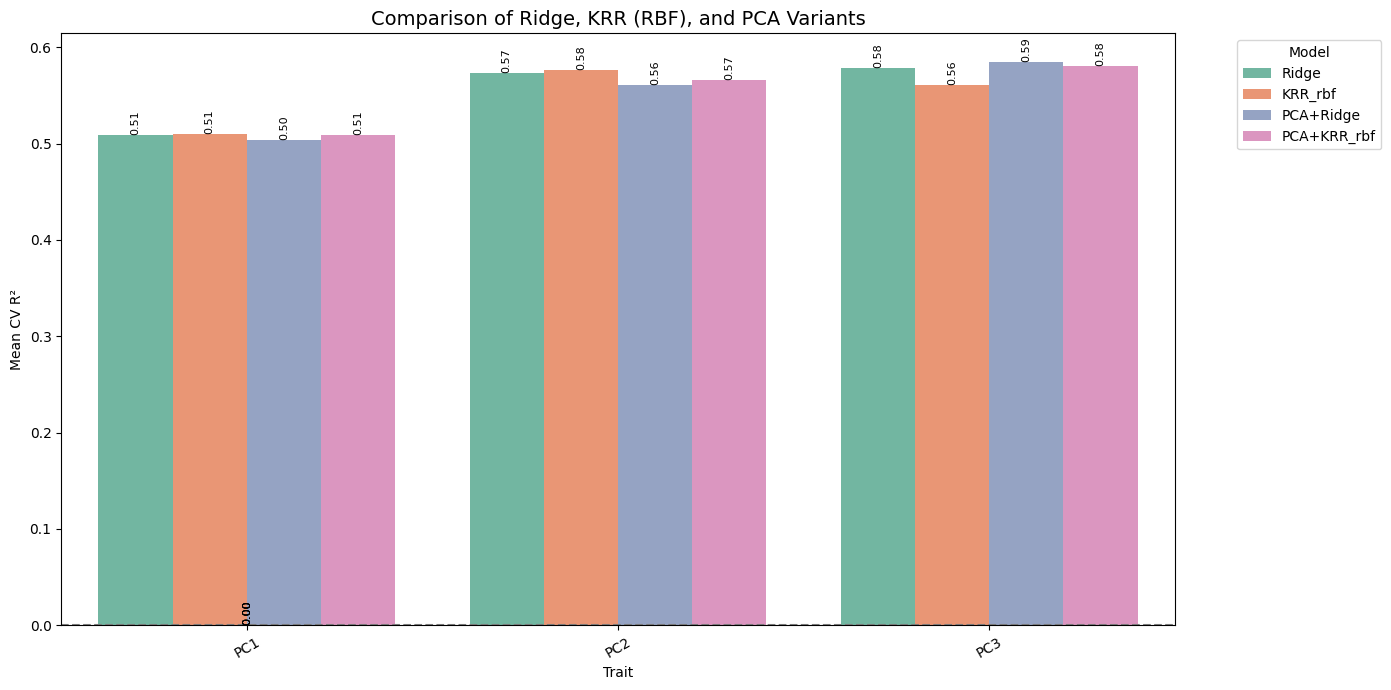

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grouped barplot (Trait × Model)
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=results_df_sensory,
    x="Trait",
    y="CV_R2_mean",
    hue="Model",
    palette="Set2"
)

# Add baseline line at R² = 0
plt.axhline(0, color="gray", linestyle="--")

# Title & labels
plt.title("Comparison of Ridge, KRR (RBF), and PCA Variants", fontsize=14)
plt.ylabel("Mean CV R²")
plt.xlabel("Trait")

# Annotate bars with values
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}",
                (p.get_x() + p.get_width() / 2., height),
                ha="center", va="bottom", fontsize=8, rotation=90)

# Rotate x-labels if traits overlap
plt.xticks(rotation=30)

# Legend outside
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [18]:
from sklearn.feature_selection import f_regression
import pandas as pd

# SNPs
X = merged_snp_sensory[[c for c in merged_snp_sensory.columns if c.startswith("GEN__")]].fillna(0)

# Sensory PCs
pcs = ["PC1", "PC2", "PC3"]

gwas_pcs = {}

for pc in pcs:
    print(f"\n=== GWAS for {pc} ===")
    y = merged_snp_sensory[pc].astype(float)
    
    f_vals, p_vals = f_regression(X, y)
    
    df = pd.DataFrame({
        "SNP": X.columns,
        "F_value": f_vals,
        "p_value": p_vals
    }).sort_values("p_value")
    
    gwas_pcs[pc] = df
    
    # Save to CSV
    filename = f"Top_SNPs_{pc}.csv"
    df.to_csv(filename, index=False)
    print(f"Saved results to {filename}")
    print(df.head(10))  # show top 10 SNPs



=== GWAS for PC1 ===
Saved results to Top_SNPs_PC1.csv
               SNP    F_value       p_value
74632  GEN__159491  31.247696  2.304461e-07
74658  GEN__159526  31.247696  2.304461e-07
75073  GEN__160143  31.247696  2.304461e-07
74868  GEN__159825  31.247696  2.304461e-07
74844  GEN__159790  31.247696  2.304461e-07
74690  GEN__159573  31.247696  2.304461e-07
74897  GEN__159869  31.247696  2.304461e-07
74688  GEN__159571  31.247696  2.304461e-07
74816  GEN__159753  31.247696  2.304461e-07
75235  GEN__160414  31.247696  2.304461e-07

=== GWAS for PC2 ===
Saved results to Top_SNPs_PC2.csv
                SNP    F_value   p_value
59321   GEN__121113  23.632795  0.000005
50531   GEN__105134  19.569220  0.000027
101533  GEN__216895  18.847951  0.000036
71550   GEN__154453  18.083603  0.000051
71497   GEN__154367  18.083603  0.000051
71467   GEN__154319  18.083603  0.000051
71496   GEN__154366  18.083603  0.000051
69069   GEN__150170  18.083603  0.000051
71445   GEN__154281  18.083603  0.0

In [19]:
from sklearn.feature_selection import f_regression
import pandas as pd

# SNP matrix
X = merged_snp_aroma[[c for c in merged_snp_aroma.columns if c.startswith("GEN__")]].fillna(0)

# Aroma traits
aroma_cols = [c for c in merged_snp_aroma.columns if c not in X.columns and merged_snp_aroma[c].dtype != "object"]

gwas_aroma = {}

for aroma in aroma_cols:
    print(f"\n=== GWAS for Aroma: {aroma} ===")
    y = merged_snp_aroma[aroma].astype(float)
    
    f_vals, p_vals = f_regression(X, y)
    
    df = pd.DataFrame({
        "SNP": X.columns,
        "F_value": f_vals,
        "p_value": p_vals
    }).sort_values("p_value")
    
    gwas_aroma[aroma] = df
    
    # Save results for each aroma trait
    filename = f"Top_SNPs_Aroma_{aroma.replace(' ', '_').replace(',', '').replace('(', '').replace(')', '')}.csv"
    df.to_csv(filename, index=False)
    
    print(f"Saved results to {filename}")
    print(df.head(10))



=== GWAS for Aroma: 1-Nonanol (Floral, waxy) ===
Saved results to Top_SNPs_Aroma_1-Nonanol_Floral_waxy.csv
                SNP     F_value       p_value
126804  GEN__268024  822.170213  1.170518e-47
193158  GEN__408839  736.193594  1.106712e-45
240869  GEN__518696  412.617957  9.109717e-36
192873  GEN__408057  412.617957  9.109717e-36
188608  GEN__397370  412.617957  9.109717e-36
193312  GEN__409313  412.617957  9.109717e-36
193671  GEN__410269  412.617957  9.109717e-36
198288  GEN__422449  412.617957  9.109717e-36
193699  GEN__410367  364.095745  9.644717e-34
193447  GEN__409648  364.095745  9.644717e-34

=== GWAS for Aroma: 1-Octen-3-ol (Mushroom, earthy) ===
Saved results to Top_SNPs_Aroma_1-Octen-3-ol_Mushroom_earthy.csv
                SNP     F_value       p_value
14530    GEN__35806  121.394326  1.697271e-18
100239  GEN__214837  121.394326  1.697271e-18
75841   GEN__161591   90.042553  2.712770e-15
75870   GEN__161652   90.042553  2.712770e-15
75886   GEN__161688   90.042553  2

In [20]:
# -------------------------------
# 3) Aroma–Sensory correlations
# -------------------------------
rows = []
for aroma in gwas_aroma.keys():
    for pc in gwas_pcs.keys():
        corr = merged_snp_aroma[aroma].corr(merged_snp_sensory[pc])
        rows.append({"Aroma": aroma, "PC": pc, "Correlation": corr})

aroma_sensory_corr = pd.DataFrame(rows)

# ذخیره نتایج
aroma_sensory_corr.to_csv("Aroma_Sensory_Correlations.csv", index=False)

print("\n=== Aroma–Sensory correlations ===")
print(aroma_sensory_corr.head(10))
print("\nSaved correlations to Aroma_Sensory_Correlations.csv")



=== Aroma–Sensory correlations ===
                                         Aroma   PC  Correlation
0                     1-Nonanol (Floral, waxy)  PC1     0.007974
1                     1-Nonanol (Floral, waxy)  PC2    -0.212018
2                     1-Nonanol (Floral, waxy)  PC3     0.036637
3              1-Octen-3-ol (Mushroom, earthy)  PC1     0.041326
4              1-Octen-3-ol (Mushroom, earthy)  PC2    -0.095159
5              1-Octen-3-ol (Mushroom, earthy)  PC3    -0.089954
6      2,3-Butanedione (Butter, creamy, sweet)  PC1     0.041326
7      2,3-Butanedione (Butter, creamy, sweet)  PC2    -0.095159
8      2,3-Butanedione (Butter, creamy, sweet)  PC3    -0.089954
9  2-Propanone, 1-methoxy- (Solvent, chemical)  PC1    -0.301788

Saved correlations to Aroma_Sensory_Correlations.csv


In [21]:
# انتخاب فقط ستون‌های واقعی آروما (حذف index و Variety)
aroma_cols = [c for c in merged_snp_aroma.columns 
              if c not in ["Variety", "index"] 
              and not c.startswith("GEN__")]

rows = []
for aroma in aroma_cols:
    for pc in ["PC1", "PC2", "PC3"]:
        corr = merged_all[aroma].corr(merged_all[pc])
        rows.append({"Aroma": aroma, "PC": pc, "Correlation": corr})

aroma_sensory_corr = pd.DataFrame(rows)
aroma_sensory_corr.to_csv("Aroma_Sensory_Correlations.csv", index=False)

print("\n=== Aroma–Sensory correlations ===")
print(aroma_sensory_corr.head())
print("Saved correlations to Aroma_Sensory_Correlations.csv")



=== Aroma–Sensory correlations ===
                             Aroma   PC  Correlation
0         1-Nonanol (Floral, waxy)  PC1     0.007974
1         1-Nonanol (Floral, waxy)  PC2    -0.212018
2         1-Nonanol (Floral, waxy)  PC3     0.036637
3  1-Octen-3-ol (Mushroom, earthy)  PC1     0.041326
4  1-Octen-3-ol (Mushroom, earthy)  PC2    -0.095159
Saved correlations to Aroma_Sensory_Correlations.csv


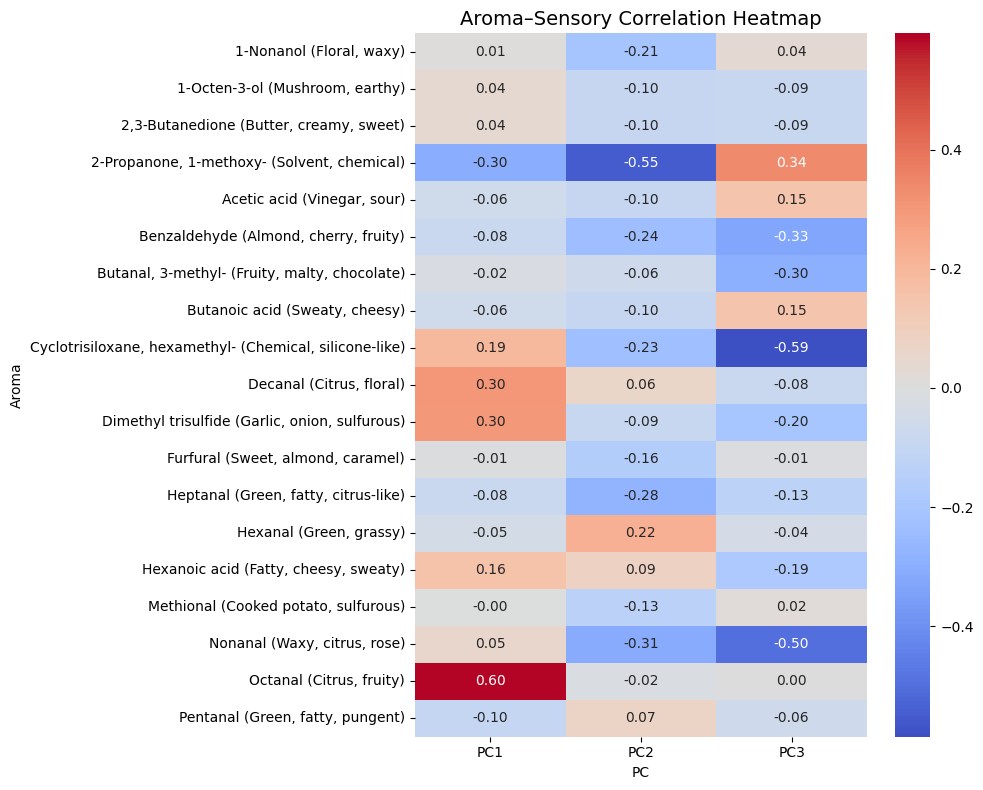

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# لود نتایج ذخیره‌شده
corr_df = pd.read_csv("Aroma_Sensory_Correlations.csv")

# pivot برای ساخت ماتریس
corr_matrix = corr_df.pivot(index="Aroma", columns="PC", values="Correlation")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Aroma–Sensory Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


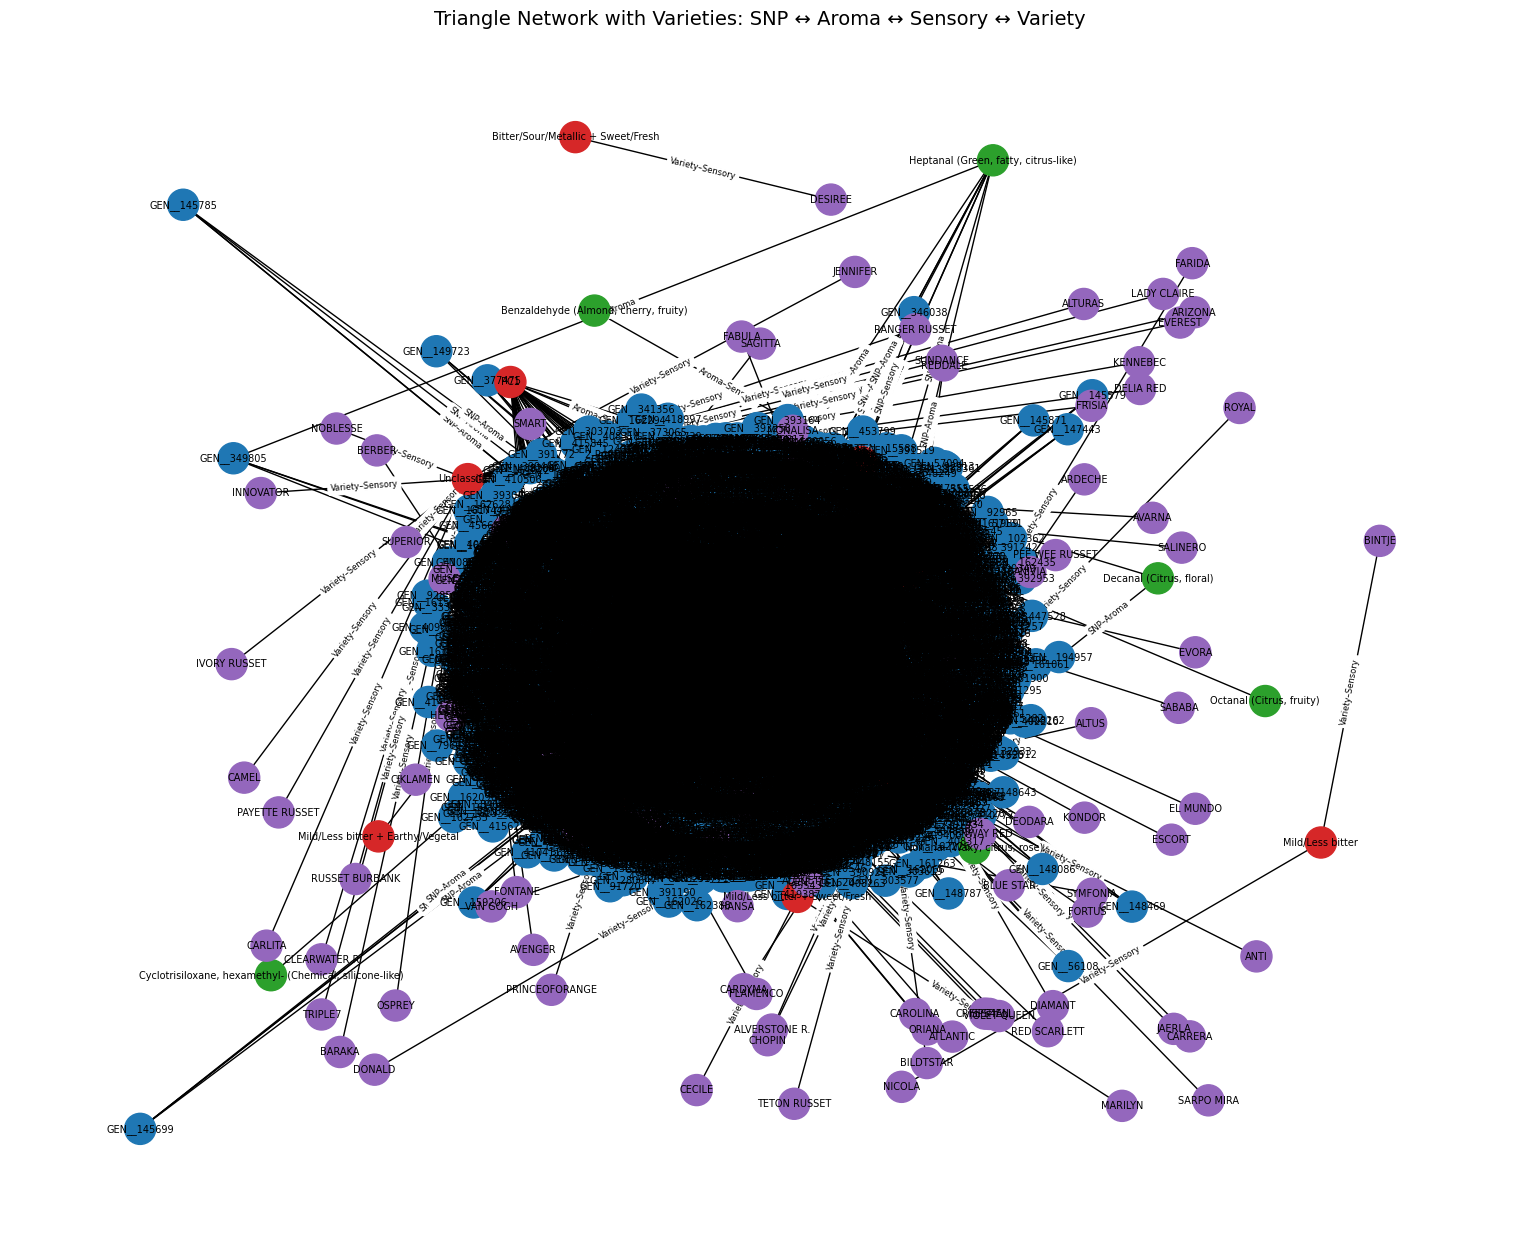

In [23]:

import networkx as nx

# بارگذاری summary
summary_sensory = pd.read_csv("variety_sensory_summary.csv")

# گراف
G = nx.Graph()

# Threshold ها
pval_thresh = 1e-5
corr_thresh = 0.3  

# SNP ↔ Aroma
for aroma, df in gwas_aroma.items():
    sig = df[df["p_value"] < pval_thresh]
    for _, row in sig.iterrows():
        G.add_node(row["SNP"], group="SNP")
        G.add_node(aroma, group="Aroma")
        G.add_edge(row["SNP"], aroma, type="SNP–Aroma", weight=-np.log10(row["p_value"]+1e-12))

# SNP ↔ Sensory PCs
for pc, df in gwas_pcs.items():
    sig = df[df["p_value"] < pval_thresh]
    for _, row in sig.iterrows():
        G.add_node(row["SNP"], group="SNP")
        G.add_node(pc, group="Sensory")
        G.add_edge(row["SNP"], pc, type="SNP–Sensory", weight=-np.log10(row["p_value"]+1e-12))

# Aroma ↔ Sensory
for _, row in aroma_sensory_corr.iterrows():
    if abs(row["Correlation"]) > corr_thresh:
        G.add_node(row["Aroma"], group="Aroma")
        G.add_node(row["PC"], group="Sensory")
        G.add_edge(row["Aroma"], row["PC"], type="Aroma–Sensory", weight=abs(row["Correlation"]))

# Variety ↔ Dominant sensory axis (from summary)
for _, row in summary_sensory.iterrows():
    variety = row["Variety"]
    axis = row["Dominant sensory axis"]

    if pd.notna(axis):
        G.add_node(variety, group="Variety")
        G.add_node(axis, group="Sensory")
        G.add_edge(variety, axis, type="Variety–Sensory", weight=1.0)

# ============================
# ترسیم
# ============================
color_map = {
    "SNP": "#1f77b4",       # آبی
    "Aroma": "#2ca02c",     # سبز
    "Sensory": "#d62728",   # قرمز
    "Variety": "#9467bd"    # بنفش
}

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(15,12))

node_colors = [color_map[G.nodes[n]["group"]] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors, font_size=7, node_size=500)

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u,v): d["type"] for u,v,d in G.edges(data=True)},
    font_size=6
)

plt.title("Triangle Network with Varieties: SNP ↔ Aroma ↔ Sensory ↔ Variety", fontsize=14)
plt.show()


In [24]:
sunmmary_sensory= pd.read_csv("variety_sensory_summary.csv")
sunmmary_sensory

,Variety,PC1,PC2,Dominant sensory axis
0,AGRIA,0.227951,-2.450256,Earthy/Vegetal
1,BERBER,-0.608510,1.382156,Sweet/Fresh
2,BILDTSTAR,0.100318,-2.677756,Earthy/Vegetal
3,BINTJE,-2.640139,-0.402412,Mild/Less bitter
4,CARRERA,3.405572,-0.021781,Bitter/Sour/Metallic
...,...,...,...,...
88,TETON RUSSET,-0.564749,-1.135384,Earthy/Vegetal
89,TRIPLE7,-0.297909,0.664750,Unclassified
90,VAN GOGH,-0.016969,-1.138031,Earthy/Vegetal
91,VE 71-105,1.529041,-0.304611,Bitter/Sour/Metallic


In [25]:

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# -----------------------
# Data
# -----------------------
aroma_cols = [c for c in merged_all.columns if "(" in c and "GEN__" not in c and "PC" not in c]
sensory_cols = ["PC1", "PC2", "PC3"]

X = merged_all[aroma_cols].fillna(0).astype(float)
Y = merged_all[sensory_cols].astype(float)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------
# Models and grids
# -----------------------
models = {
    "LinearRegression": (
        Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
        {}
    ),
    "Ridge": (
        Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
        {"model__alpha": [0.1, 1, 10, 100]}
    ),
    "KernelRidge": (
        Pipeline([("scaler", StandardScaler()), ("model", KernelRidge(kernel="rbf"))]),
        {"model__alpha": [0.01, 0.1, 1, 10],
         "model__gamma": [1e-3, 1e-2, 0.1, 1]}
    ),
    "SVR": (
        Pipeline([("scaler", StandardScaler()), ("model", SVR(kernel="rbf"))]),
        {"model__C": [0.1, 1, 10],
         "model__gamma": ["scale", "auto", 0.01, 0.1]}
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {"n_estimators": [100, 300],
         "max_depth": [None, 5, 10]}
    ),
    "XGBoost": (
        XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
        {"n_estimators": [100, 300],
         "learning_rate": [0.01, 0.1, 0.3],
         "max_depth": [3, 5, 7]}
    )
}

# -----------------------
# Training loop
# -----------------------
results = []

for pc in sensory_cols:
    y = Y[pc].values

    for model_name, (estimator, param_grid) in models.items():
        print(f"\n=== {model_name} for {pc} ===")
        grid = GridSearchCV(
            estimator,
            param_grid,
            cv=cv,
            scoring="r2",
            n_jobs=-1
        )
        grid.fit(X, y)

        results.append({
            "PC": pc,
            "Model": model_name,
            "Best_params": grid.best_params_,
            "CV_R2_mean": grid.best_score_
        })

results_df = pd.DataFrame(results)
print("\n=== Final Comparison (GCMS → Sensory PCs) ===")
print(results_df.sort_values(["PC", "CV_R2_mean"], ascending=[True, False]))

# Save results
results_df.to_csv("gcms_to_sensory_model_comparison.csv", index=False)



=== LinearRegression for PC1 ===

=== Ridge for PC1 ===

=== KernelRidge for PC1 ===

=== SVR for PC1 ===

=== RandomForest for PC1 ===

=== XGBoost for PC1 ===

=== LinearRegression for PC2 ===

=== Ridge for PC2 ===

=== KernelRidge for PC2 ===

=== SVR for PC2 ===

=== RandomForest for PC2 ===

=== XGBoost for PC2 ===

=== LinearRegression for PC3 ===

=== Ridge for PC3 ===

=== KernelRidge for PC3 ===

=== SVR for PC3 ===

=== RandomForest for PC3 ===

=== XGBoost for PC3 ===

=== Final Comparison (GCMS → Sensory PCs) ===
     PC             Model                                        Best_params  \
5   PC1           XGBoost  {'learning_rate': 0.01, 'max_depth': 3, 'n_est...   
2   PC1       KernelRidge         {'model__alpha': 0.1, 'model__gamma': 0.1}   
3   PC1               SVR             {'model__C': 10, 'model__gamma': 0.01}   
4   PC1      RandomForest              {'max_depth': 5, 'n_estimators': 300}   
1   PC1             Ridge                               {'model__al

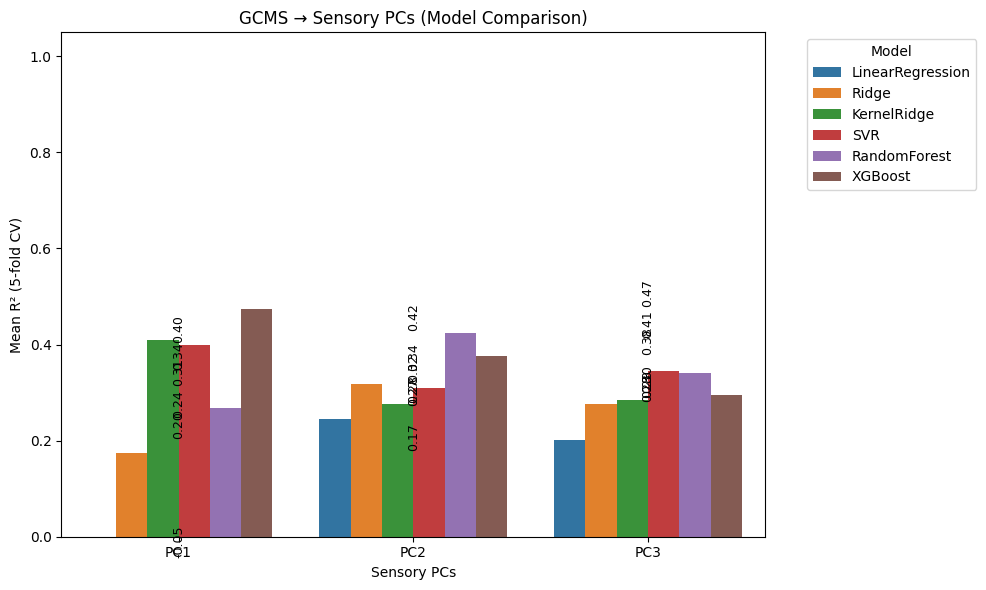

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="PC",
    y="CV_R2_mean",
    hue="Model",
    palette="tab10"
)

# نوشتن درصد یا مقدار R2 روی هر ستون
for i, row in results_df.iterrows():
    plt.text(
        x=i % len(results_df["PC"].unique()), 
        y=row["CV_R2_mean"] + 0.01,
        s=f"{row['CV_R2_mean']:.2f}",
        ha="center", fontsize=9, rotation=90
    )

plt.title("GCMS → Sensory PCs (Model Comparison)")
plt.ylabel("Mean R² (5-fold CV)")
plt.xlabel("Sensory PCs")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


In [34]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# -----------------------
# Data
# -----------------------
# Assuming merged_all is already loaded
aroma_cols = [c for c in merged_all.columns if "(" in c and "GEN__" not in c and "PC" not in c]
sensory_cols = ["PC1", "PC2", "PC3"]

X = merged_all[aroma_cols].fillna(0).astype(float)
Y = merged_all[sensory_cols].astype(float)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------
# PCA / PLS toggle (set to True to use)
# -----------------------
USE_PCA = False
USE_PLS = False
N_COMPONENTS = 10  # adjust based on variance explained

if USE_PCA:
    pca = PCA(n_components=N_COMPONENTS, random_state=42)
    X = pca.fit_transform(X)

if USE_PLS:
    pls = PLSRegression(n_components=min(N_COMPONENTS, X.shape[1]))
    X, _ = pls.fit_transform(X, Y)

# -----------------------
# Models and grids
# -----------------------
models = {
    "LinearRegression": (
        Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
        {}
    ),
    "Ridge": (
        Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
        {"model__alpha": [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1000]}
    ),
    "KernelRidge": (
        Pipeline([("scaler", StandardScaler()), ("model", KernelRidge())]),
        {"model__alpha": [1e-3, 1e-2, 0.1, 1, 10],
         "model__gamma": [1e-4, 1e-3, 1e-2, 0.1, 1],
         "model__kernel": ["rbf", "poly", "sigmoid"]}
    ),
    "SVR": (
        Pipeline([("scaler", StandardScaler()), ("model", SVR())]),
        {"model__C": [0.01, 0.1, 1, 10, 100],
         "model__gamma": ["scale", "auto", 1e-3, 1e-2, 0.1],
         "model__epsilon": [0.01, 0.1, 0.5, 1.0],
         "model__kernel": ["rbf", "poly"]}
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {"n_estimators": [200, 500, 800],
         "max_depth": [None, 5, 10, 20],
         "max_features": ["sqrt", "log2", None],
         "min_samples_split": [2, 5, 10],
         "min_samples_leaf": [1, 2, 4]}
    ),
    "XGBoost": (
        XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
        {"n_estimators": [300, 500, 800],
         "learning_rate": [0.01, 0.05, 0.1, 0.3],
         "max_depth": [3, 5, 7, 9],
         "subsample": [0.6, 0.8, 1.0],
         "colsample_bytree": [0.6, 0.8, 1.0],
         "reg_alpha": [0, 0.1, 1],
         "reg_lambda": [1, 5, 10]}
    )
}

# -----------------------
# Training loop
# -----------------------
results = []

for pc in sensory_cols:
    y = Y[pc].values

    for model_name, (estimator, param_grid) in models.items():
        print(f"\n=== {model_name} for {pc} ===")
        grid = GridSearchCV(
            estimator,
            param_grid,
            cv=cv,
            scoring="r2",
            n_jobs=-1
        )
        grid.fit(X, y)

        results.append({
            "PC": pc,
            "Model": model_name,
            "Best_params": grid.best_params_,
            "CV_R2_mean": grid.best_score_
        })

results_df = pd.DataFrame(results)
print("\n=== Final Comparison (GCMS → Sensory PCs) ===")
print(results_df.sort_values(["PC", "CV_R2_mean"], ascending=[True, False]))

# Save results
results_df.to_csv("gcms_to_sensory_model_comparison.csv", index=False)



=== LinearRegression for PC1 ===

=== Ridge for PC1 ===

=== KernelRidge for PC1 ===

=== SVR for PC1 ===

=== RandomForest for PC1 ===

=== XGBoost for PC1 ===

=== LinearRegression for PC2 ===

=== Ridge for PC2 ===

=== KernelRidge for PC2 ===

=== SVR for PC2 ===

=== RandomForest for PC2 ===

=== XGBoost for PC2 ===

=== LinearRegression for PC3 ===

=== Ridge for PC3 ===

=== KernelRidge for PC3 ===

=== SVR for PC3 ===

=== RandomForest for PC3 ===

=== XGBoost for PC3 ===

=== Final Comparison (GCMS → Sensory PCs) ===
     PC             Model                                        Best_params  \
5   PC1           XGBoost  {'colsample_bytree': 0.6, 'learning_rate': 0.0...   
2   PC1       KernelRidge  {'model__alpha': 0.1, 'model__gamma': 0.1, 'mo...   
3   PC1               SVR  {'model__C': 10, 'model__epsilon': 0.1, 'model...   
4   PC1      RandomForest  {'max_depth': 10, 'max_features': 'sqrt', 'min...   
1   PC1             Ridge                               {'model__al

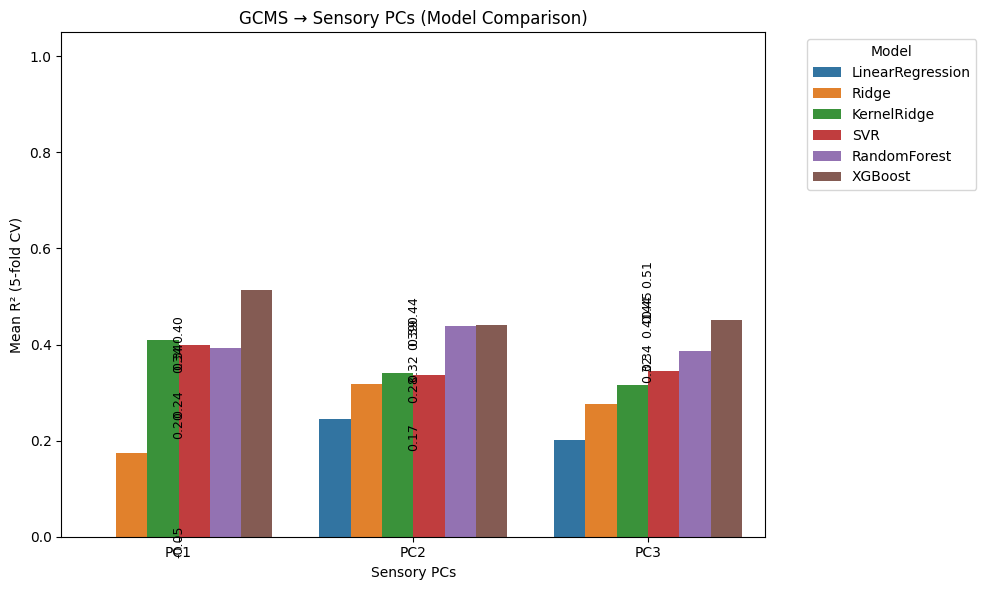

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="PC",
    y="CV_R2_mean",
    hue="Model",
    palette="tab10"
)

# نوشتن درصد یا مقدار R2 روی هر ستون
for i, row in results_df.iterrows():
    plt.text(
        x=i % len(results_df["PC"].unique()), 
        y=row["CV_R2_mean"] + 0.01,
        s=f"{row['CV_R2_mean']:.2f}",
        ha="center", fontsize=9, rotation=90
    )

plt.title("GCMS → Sensory PCs (Model Comparison)")
plt.ylabel("Mean R² (5-fold CV)")
plt.xlabel("Sensory PCs")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression, LassoCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import SelectKBest, f_regression, SelectFromModel
from sklearn.feature_selection import RFE

# -----------------------
# Data
# -----------------------
aroma_cols = [c for c in merged_all.columns if "(" in c and "GEN__" not in c and "PC" not in c]
sensory_cols = ["PC1", "PC2", "PC3"]

X = merged_all[aroma_cols].fillna(0).astype(float)
Y = merged_all[sensory_cols].astype(float)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------
# Dimensionality Reduction / Feature Selection Options
# -----------------------
N_COMPONENTS = 10

feature_selectors = {
    "Raw": None,
    "PCA": PCA(n_components=N_COMPONENTS, random_state=42),
    "PLS": PLSRegression(n_components=min(N_COMPONENTS, X.shape[1])),
    "SelectKBest": SelectKBest(score_func=f_regression, k=30),
    "LassoSelect": SelectFromModel(LassoCV(cv=5, random_state=42)),
    "RFE": RFE(estimator=LinearRegression(), n_features_to_select=20)
}

# -----------------------
# Models and grids
# -----------------------
models = {
    "LinearRegression": (
        Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
        {}
    ),
    "Ridge": (
        Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
        {"model__alpha": [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1000]}
    ),
    "KernelRidge": (
        Pipeline([("scaler", StandardScaler()), ("model", KernelRidge())]),
        {"model__alpha": [1e-3, 1e-2, 0.1, 1, 10],
         "model__gamma": [1e-4, 1e-3, 1e-2, 0.1, 1],
         "model__kernel": ["rbf", "poly", "sigmoid"]}
    ),
    "SVR": (
        Pipeline([("scaler", StandardScaler()), ("model", SVR())]),
        {"model__C": [0.01, 0.1, 1, 10, 100],
         "model__gamma": ["scale", "auto", 1e-3, 1e-2, 0.1],
         "model__epsilon": [0.01, 0.1, 0.5, 1.0],
         "model__kernel": ["rbf", "poly"]}
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {"n_estimators": [200, 500, 800],
         "max_depth": [None, 5, 10, 20],
         "max_features": ["sqrt", "log2", None],
         "min_samples_split": [2, 5, 10],
         "min_samples_leaf": [1, 2, 4]}
    ),
    "XGBoost": (
        XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
        {"n_estimators": [300, 500, 800],
         "learning_rate": [0.01, 0.05, 0.1, 0.3],
         "max_depth": [3, 5, 7, 9],
         "subsample": [0.6, 0.8, 1.0],
         "colsample_bytree": [0.6, 0.8, 1.0],
         "reg_alpha": [0, 0.1, 1],
         "reg_lambda": [1, 5, 10]}
    )
}

# -----------------------
# Training loop
# -----------------------
results = []

for pc in sensory_cols:
    y = Y[pc].values

    for fs_name, selector in feature_selectors.items():
        # Apply feature selection / transformation
        if selector is None:
            X_fs = X
        elif fs_name == "PLS":
            X_fs, _ = selector.fit_transform(X, y.reshape(-1, 1))
        else:
            X_fs = selector.fit_transform(X, y)

        for model_name, (estimator, param_grid) in models.items():
            print(f"\n=== {model_name} for {pc} with {fs_name} ===")
            grid = GridSearchCV(
                estimator,
                param_grid,
                cv=cv,
                scoring="r2",
                n_jobs=-1
            )
            grid.fit(X_fs, y)

            results.append({
                "PC": pc,
                "Selector": fs_name,
                "Model": model_name,
                "Best_params": grid.best_params_,
                "CV_R2_mean": grid.best_score_
            })

results_df = pd.DataFrame(results)
print("\n=== Final Comparison (GCMS → Sensory PCs) ===")
print(results_df.sort_values(["PC", "CV_R2_mean"], ascending=[True, False]))

# Save results
results_df.to_csv("gcms_to_sensory_model_comparison_with_FS.csv", index=False)



=== LinearRegression for PC1 with Raw ===

=== Ridge for PC1 with Raw ===

=== KernelRidge for PC1 with Raw ===

=== SVR for PC1 with Raw ===

=== RandomForest for PC1 with Raw ===

=== XGBoost for PC1 with Raw ===

=== LinearRegression for PC1 with PCA ===

=== Ridge for PC1 with PCA ===

=== KernelRidge for PC1 with PCA ===

=== SVR for PC1 with PCA ===

=== RandomForest for PC1 with PCA ===

=== XGBoost for PC1 with PCA ===

=== LinearRegression for PC1 with PLS ===

=== Ridge for PC1 with PLS ===

=== KernelRidge for PC1 with PLS ===

=== SVR for PC1 with PLS ===

=== RandomForest for PC1 with PLS ===

=== XGBoost for PC1 with PLS ===


c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:783: UserWarning:

k=30 is greater than n_features=19. All the features will be returned.




=== LinearRegression for PC1 with SelectKBest ===

=== Ridge for PC1 with SelectKBest ===

=== KernelRidge for PC1 with SelectKBest ===

=== SVR for PC1 with SelectKBest ===

=== RandomForest for PC1 with SelectKBest ===

=== XGBoost for PC1 with SelectKBest ===


Selected top SNPs: 50


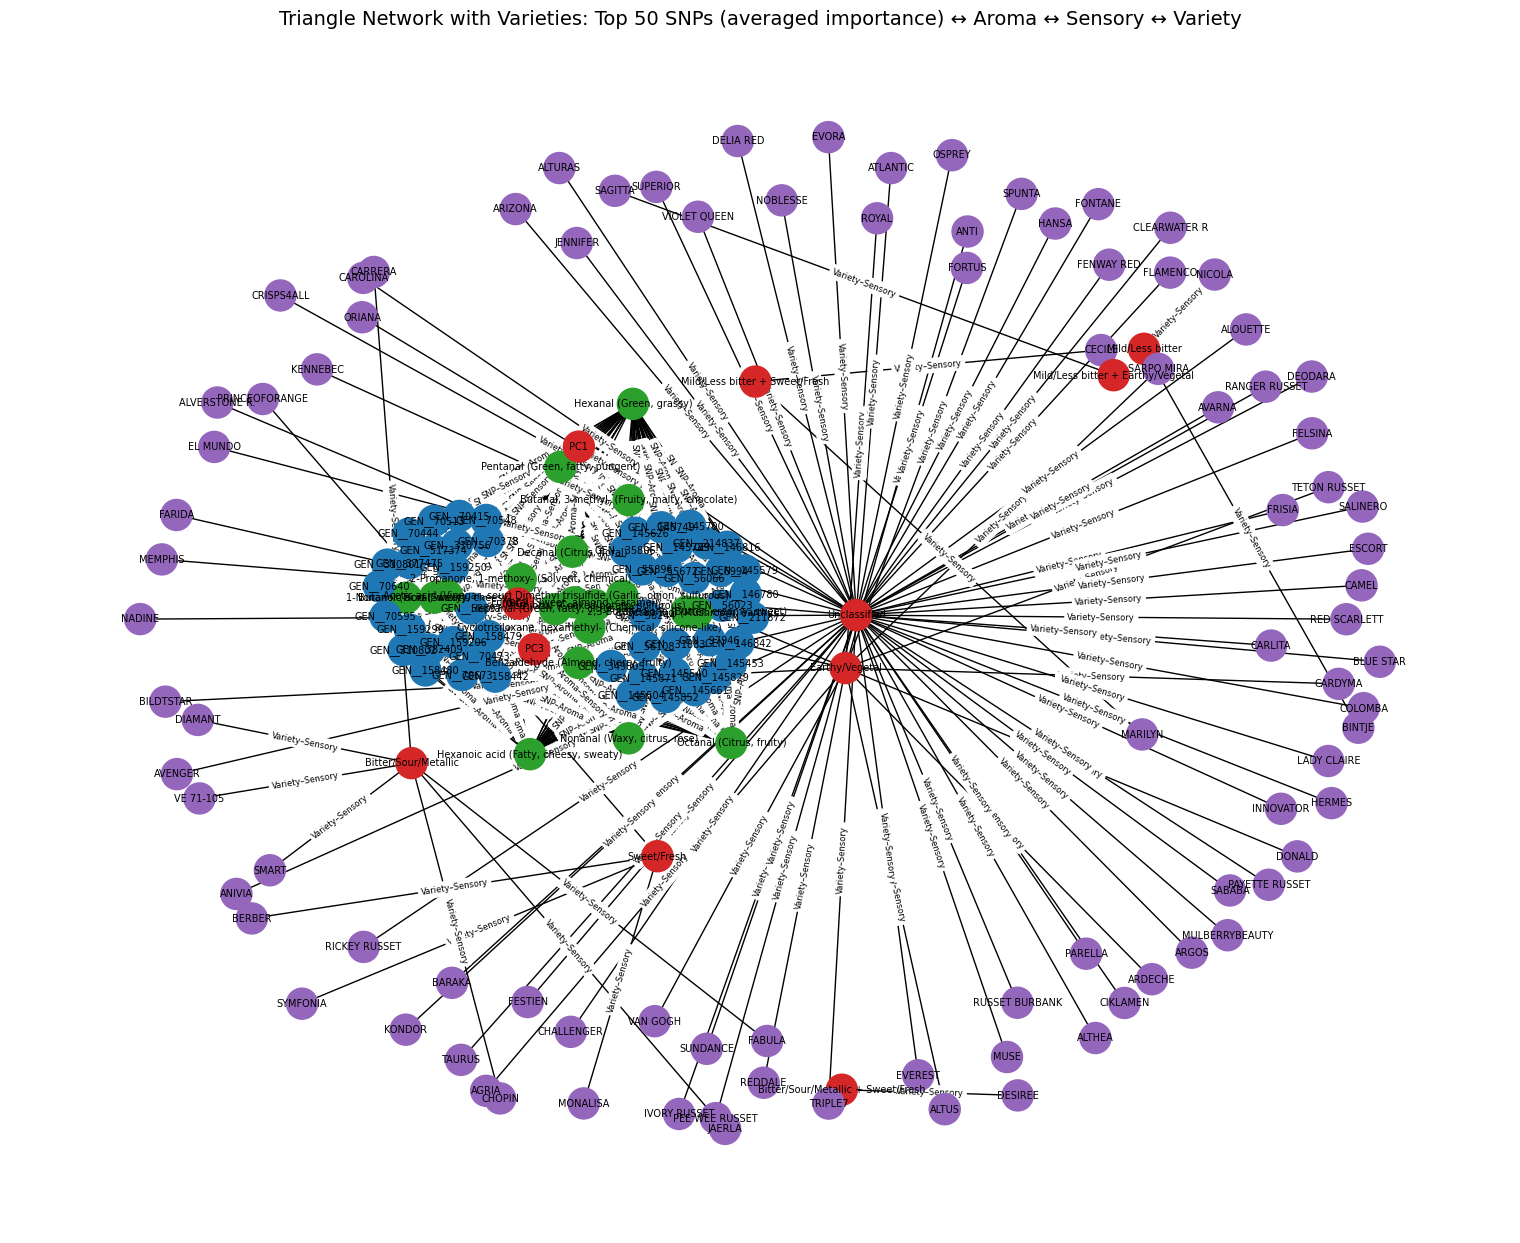

In [27]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# =======================
# Load data
# =======================
summary_sensory = pd.read_csv("variety_sensory_summary.csv")

# =======================
# Collect all SNP–Trait results
# =======================
all_snps = []

# From aroma
for aroma, df in gwas_aroma.items():
    tmp = df.copy()
    tmp["Trait"] = aroma
    tmp["Type"] = "Aroma"
    all_snps.append(tmp)

# From sensory PCs
for pc, df in gwas_pcs.items():
    tmp = df.copy()
    tmp["Trait"] = pc
    tmp["Type"] = "Sensory"
    all_snps.append(tmp)

all_snps_df = pd.concat(all_snps, ignore_index=True)

# =======================
# SNP importance (average -log10 p-value across traits)
# =======================
all_snps_df["score"] = -np.log10(all_snps_df["p_value"] + 1e-12)

snp_scores = (
    all_snps_df.groupby("SNP")["score"]
    .mean()   # could use .median() for robustness
    .reset_index()
    .rename(columns={"score": "avg_score"})
)

# Select top 50 SNPs
top_snps = snp_scores.nlargest(50, "avg_score")["SNP"].tolist()
top_snp_set = set(top_snps)

print("Selected top SNPs:", len(top_snp_set))

# =======================
# Build graph
# =======================
G = nx.Graph()
corr_thresh = 0.3  

# SNP ↔ Aroma
for aroma, df in gwas_aroma.items():
    sig = df[df["SNP"].isin(top_snp_set)]
    for _, row in sig.iterrows():
        G.add_node(row["SNP"], group="SNP")
        G.add_node(aroma, group="Aroma")
        G.add_edge(
            row["SNP"], aroma,
            type="SNP–Aroma",
            weight=-np.log10(row["p_value"] + 1e-12)
        )

# SNP ↔ Sensory PCs
for pc, df in gwas_pcs.items():
    sig = df[df["SNP"].isin(top_snp_set)]
    for _, row in sig.iterrows():
        G.add_node(row["SNP"], group="SNP")
        G.add_node(pc, group="Sensory")
        G.add_edge(
            row["SNP"], pc,
            type="SNP–Sensory",
            weight=-np.log10(row["p_value"] + 1e-12)
        )

# Aroma ↔ Sensory
for _, row in aroma_sensory_corr.iterrows():
    if abs(row["Correlation"]) > corr_thresh:
        G.add_node(row["Aroma"], group="Aroma")
        G.add_node(row["PC"], group="Sensory")
        G.add_edge(
            row["Aroma"], row["PC"],
            type="Aroma–Sensory",
            weight=abs(row["Correlation"])
        )

# Variety ↔ Dominant sensory axis
for _, row in summary_sensory.iterrows():
    variety = row["Variety"]
    axis = row["Dominant sensory axis"]
    if pd.notna(axis):
        G.add_node(variety, group="Variety")
        G.add_node(axis, group="Sensory")
        G.add_edge(
            variety, axis,
            type="Variety–Sensory",
            weight=1.0
        )

# =======================
# Draw network
# =======================
color_map = {
    "SNP": "#1f77b4",       # blue
    "Aroma": "#2ca02c",     # green
    "Sensory": "#d62728",   # red
    "Variety": "#9467bd"    # purple
}

pos = nx.spring_layout(G, seed=42, k=0.6)

plt.figure(figsize=(15,12))
node_colors = [color_map[G.nodes[n]["group"]] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors, font_size=7, node_size=500)

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u,v): d["type"] for u,v,d in G.edges(data=True)},
    font_size=6
)

plt.title("Triangle Network with Varieties: Top 50 SNPs (averaged importance) ↔ Aroma ↔ Sensory ↔ Variety", fontsize=14)
plt.show()


Selected top SNPs: 10


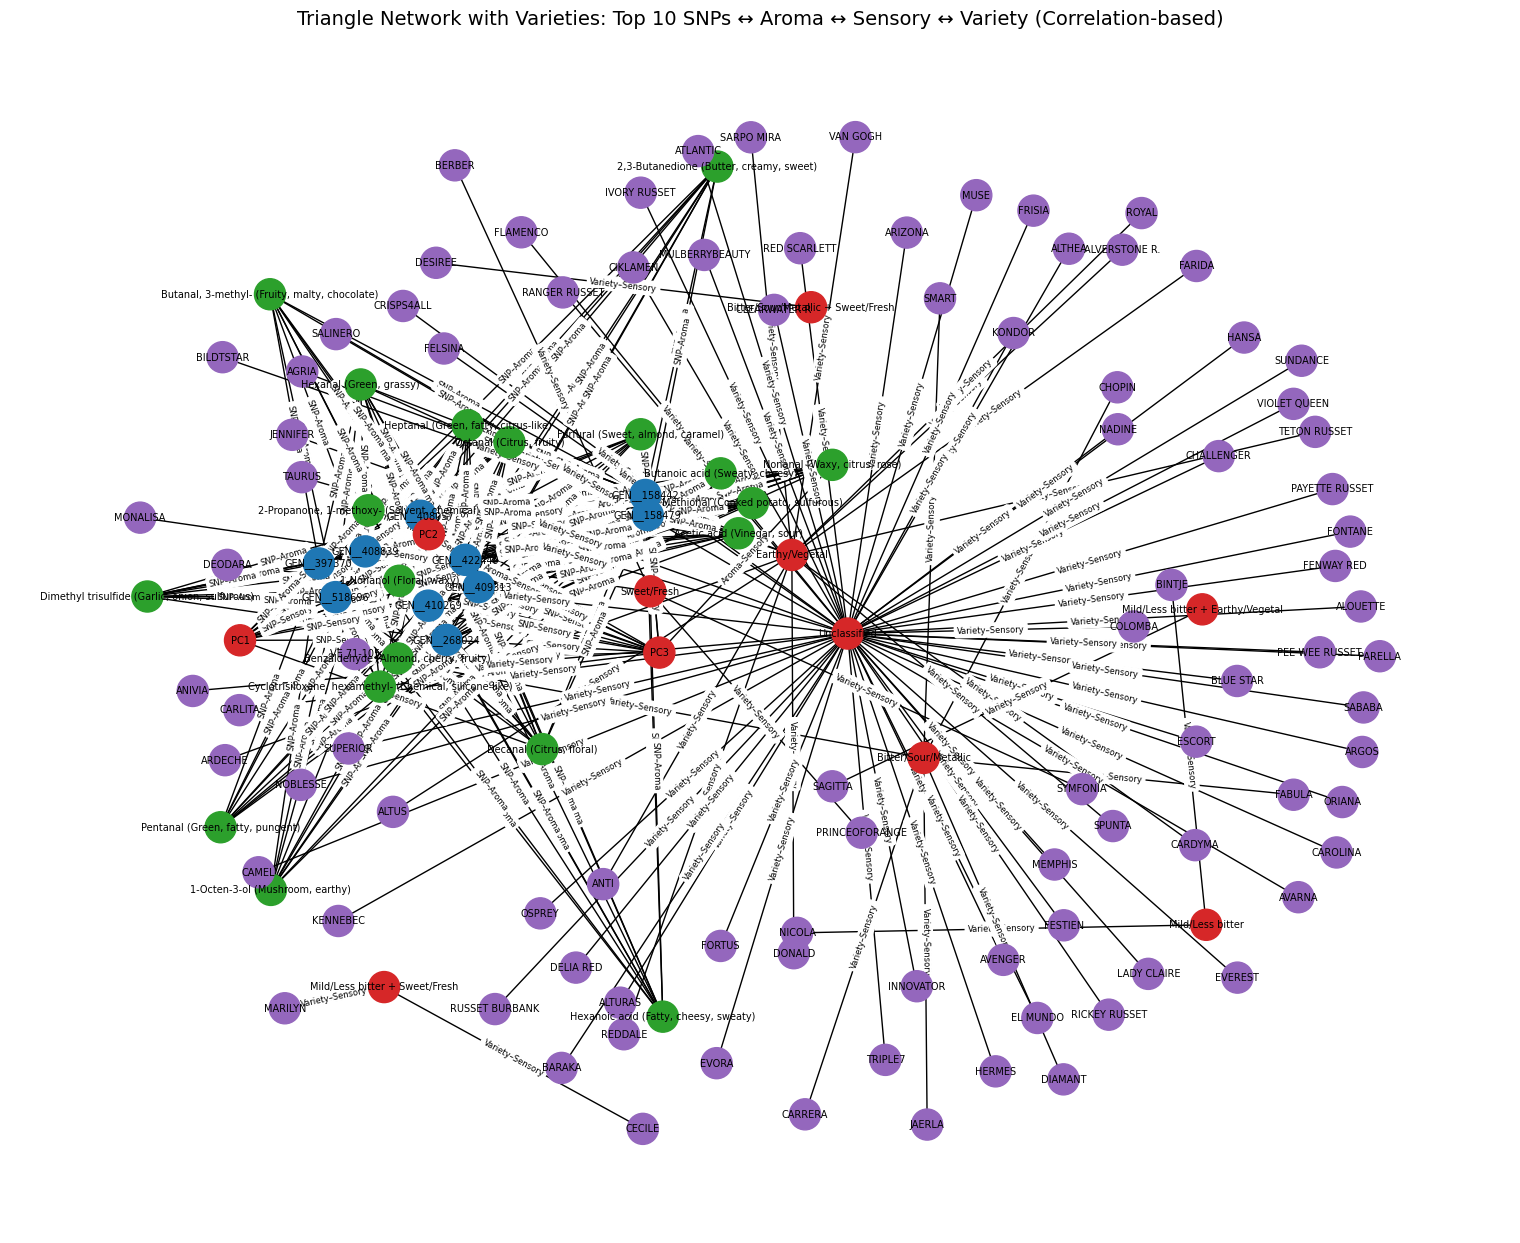

In [28]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Load data
# -----------------------
summary_sensory = pd.read_csv("variety_sensory_summary.csv")

# -----------------------
# Collect all SNP–Trait results
# -----------------------
all_snps = []

# From aroma
for aroma, df in gwas_aroma.items():
    tmp = df.copy()
    tmp["Trait"] = aroma
    tmp["Type"] = "Aroma"
    all_snps.append(tmp)

# From sensory PCs
for pc, df in gwas_pcs.items():
    tmp = df.copy()
    tmp["Trait"] = pc
    tmp["Type"] = "Sensory"
    all_snps.append(tmp)

all_snps_df = pd.concat(all_snps, ignore_index=True)

# -----------------------
# SNP importance (use min p-value across traits)
# -----------------------
snp_scores = (
    all_snps_df.groupby("SNP")["p_value"]
    .min()   # best p-value across traits
    .reset_index()
    .rename(columns={"p_value": "min_p"})
)

# Select top SNPs (say top 10)
top_snps = snp_scores.nsmallest(10, "min_p")["SNP"].tolist()
top_snp_set = set(top_snps)

print("Selected top SNPs:", len(top_snp_set))

# -----------------------
# Build graph (based on correlation + selected SNPs)
# -----------------------
G = nx.Graph()
corr_thresh = 0.3  

# SNP ↔ Aroma (only top SNPs)
for aroma, df in gwas_aroma.items():
    sig = df[df["SNP"].isin(top_snp_set)]
    for _, row in sig.iterrows():
        G.add_node(row["SNP"], group="SNP")
        G.add_node(aroma, group="Aroma")
        G.add_edge(
            row["SNP"], aroma,
            type="SNP–Aroma",
            weight=-np.log10(row["p_value"] + 1e-12)
        )

# SNP ↔ Sensory PCs (only top SNPs)
for pc, df in gwas_pcs.items():
    sig = df[df["SNP"].isin(top_snp_set)]
    for _, row in sig.iterrows():
        G.add_node(row["SNP"], group="SNP")
        G.add_node(pc, group="Sensory")
        G.add_edge(
            row["SNP"], pc,
            type="SNP–Sensory",
            weight=-np.log10(row["p_value"] + 1e-12)
        )

# Aroma ↔ Sensory (based on correlation threshold)
for _, row in aroma_sensory_corr.iterrows():
    if abs(row["Correlation"]) > corr_thresh:
        G.add_node(row["Aroma"], group="Aroma")
        G.add_node(row["PC"], group="Sensory")
        G.add_edge(
            row["Aroma"], row["PC"],
            type="Aroma–Sensory",
            weight=abs(row["Correlation"])
        )

# Variety ↔ Dominant sensory axis
for _, row in summary_sensory.iterrows():
    variety = row["Variety"]
    axis = row["Dominant sensory axis"]
    if pd.notna(axis):
        G.add_node(variety, group="Variety")
        G.add_node(axis, group="Sensory")
        G.add_edge(
            variety, axis,
            type="Variety–Sensory",
            weight=1.0
        )

# -----------------------
# Draw network
# -----------------------
color_map = {
    "SNP": "#1f77b4",       # blue
    "Aroma": "#2ca02c",     # green
    "Sensory": "#d62728",   # red
    "Variety": "#9467bd"    # purple
}

pos = nx.spring_layout(G, seed=42, k=0.6)

plt.figure(figsize=(15,12))
node_colors = [color_map[G.nodes[n]["group"]] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors, font_size=7, node_size=500)

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u,v): d["type"] for u,v,d in G.edges(data=True)},
    font_size=6
)

plt.title("Triangle Network with Varieties: Top 10 SNPs ↔ Aroma ↔ Sensory ↔ Variety (Correlation-based)", fontsize=14)
plt.show()


Selected top SNPs: 5


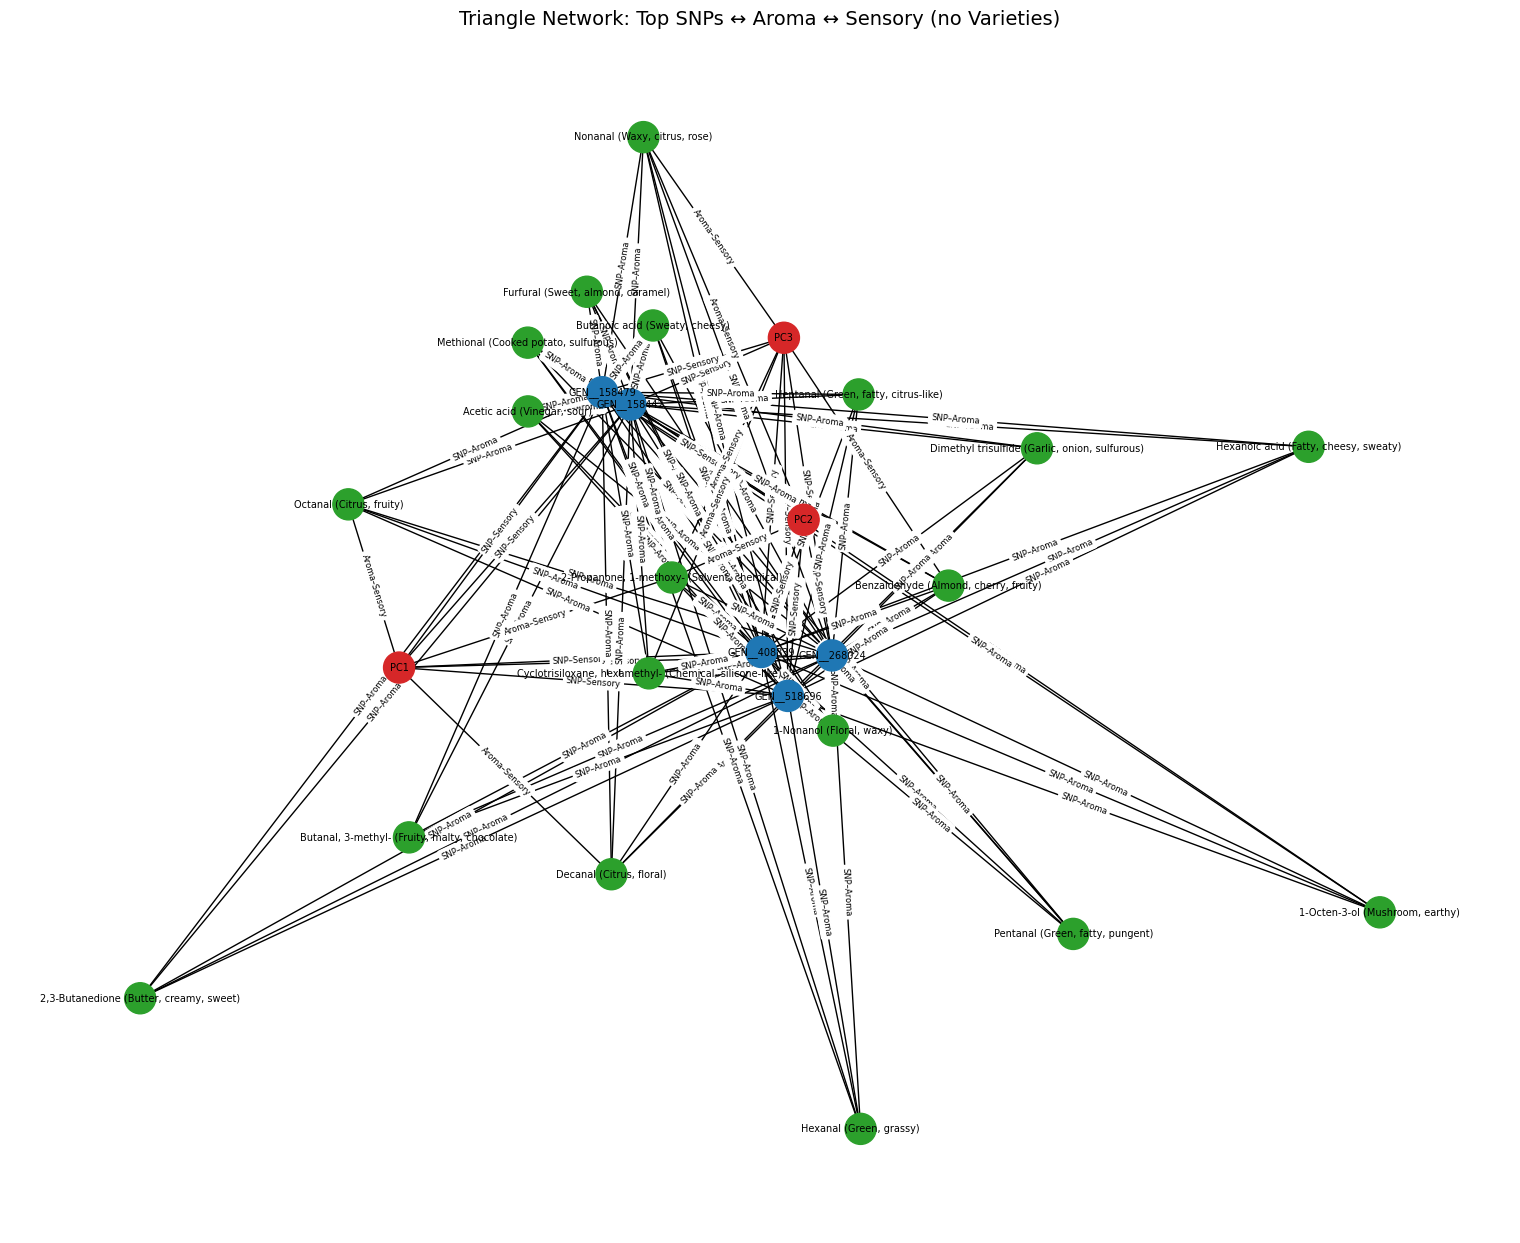

In [29]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Load data
# -----------------------
summary_sensory = pd.read_csv("variety_sensory_summary.csv")

# -----------------------
# Collect all SNP–Trait results
# -----------------------
all_snps = []

# From aroma
for aroma, df in gwas_aroma.items():
    tmp = df.copy()
    tmp["Trait"] = aroma
    tmp["Type"] = "Aroma"
    all_snps.append(tmp)

# From sensory PCs
for pc, df in gwas_pcs.items():
    tmp = df.copy()
    tmp["Trait"] = pc
    tmp["Type"] = "Sensory"
    all_snps.append(tmp)

all_snps_df = pd.concat(all_snps, ignore_index=True)

# -----------------------
# SNP importance (min p-value across traits)
# -----------------------
snp_scores = (
    all_snps_df.groupby("SNP")["p_value"]
    .min()
    .reset_index()
    .rename(columns={"p_value": "min_p"})
)

# Select top SNPs (e.g., top 10)
top_snps = snp_scores.nsmallest(5, "min_p")["SNP"].tolist()
top_snp_set = set(top_snps)

print("Selected top SNPs:", len(top_snp_set))

# -----------------------
# Build graph (no varieties)
# -----------------------
G = nx.Graph()
corr_thresh = 0.3  

# SNP ↔ Aroma
for aroma, df in gwas_aroma.items():
    sig = df[df["SNP"].isin(top_snp_set)]
    for _, row in sig.iterrows():
        G.add_node(row["SNP"], group="SNP")
        G.add_node(aroma, group="Aroma")
        G.add_edge(
            row["SNP"], aroma,
            type="SNP–Aroma",
            weight=-np.log10(row["p_value"] + 1e-12)
        )

# SNP ↔ Sensory PCs
for pc, df in gwas_pcs.items():
    sig = df[df["SNP"].isin(top_snp_set)]
    for _, row in sig.iterrows():
        G.add_node(row["SNP"], group="SNP")
        G.add_node(pc, group="Sensory")
        G.add_edge(
            row["SNP"], pc,
            type="SNP–Sensory",
            weight=-np.log10(row["p_value"] + 1e-12)
        )

# Aroma ↔ Sensory
for _, row in aroma_sensory_corr.iterrows():
    if abs(row["Correlation"]) > corr_thresh:
        G.add_node(row["Aroma"], group="Aroma")
        G.add_node(row["PC"], group="Sensory")
        G.add_edge(
            row["Aroma"], row["PC"],
            type="Aroma–Sensory",
            weight=abs(row["Correlation"])
        )

# -----------------------
# Draw network
# -----------------------
color_map = {
    "SNP": "#1f77b4",       # blue
    "Aroma": "#2ca02c",     # green
    "Sensory": "#d62728"    # red
}

pos = nx.spring_layout(G, seed=42, k=0.6)

plt.figure(figsize=(15,12))
node_colors = [color_map[G.nodes[n]["group"]] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors, font_size=7, node_size=500)

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u,v): d["type"] for u,v,d in G.edges(data=True)},
    font_size=6
)

plt.title("Triangle Network: Top SNPs ↔ Aroma ↔ Sensory (no Varieties)", fontsize=14)
plt.show()


In [30]:
merged_snp_aroma

,GEN__7,GEN__10,GEN__13,GEN__17,GEN__21,GEN__22,GEN__39,GEN__48,GEN__49,GEN__54,...,"Decanal (Citrus, floral)","Dimethyl trisulfide (Garlic, onion, sulfurous)","Furfural (Sweet, almond, caramel)","Heptanal (Green, fatty, citrus-like)","Hexanal (Green, grassy)","Hexanoic acid (Fatty, cheesy, sweaty)","Methional (Cooked potato, sulfurous)","Nonanal (Waxy, citrus, rose)","Octanal (Citrus, fruity)","Pentanal (Green, fatty, pungent)"
ADORA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.907991e+06,0.000000e+00,0.0,0.000000,0.000000e+00,1.000677e+06,0.0,1.794650e+07,2.410517e+06,0.000000e+00
AGRIA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.528243e+06,5.462518e+05,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,1.208483e+07,1.109952e+06,1.108374e+06
ALOUETTE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.278052e+06,0.000000e+00,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,1.214480e+07,1.074904e+06,0.000000e+00
ALTHEA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.166506e+07,0.000000e+00,0.0,0.000000,0.000000e+00,2.108002e+06,0.0,3.830736e+07,0.000000e+00,3.065847e+06
ALTURAS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.824053e+04,0.000000e+00,0.0,121474.466835,2.528957e+06,0.000000e+00,0.0,2.163269e+07,1.467772e+06,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TETON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.556748e+06,0.000000e+00,0.0,573917.320668,9.352888e+05,0.000000e+00,0.0,1.392716e+07,1.310231e+06,0.000000e+00
TRIPLE7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.059158e+06,0.000000e+00,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,3.239183e+06,0.000000e+00,0.000000e+00
VANGOGH,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.681949e+03,1.569901e+06,0.0,0.000000,0.000000e+00,0.000000e+00,0.0,1.710367e+07,7.971461e+05,0.000000e+00
VE71-105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,7.603735e+06,1.864674e+06,0.0,0.000000,0.000000e+00,3.386848e+05,0.0,2.156410e+07,2.081086e+06,0.000000e+00


Top shared SNPs: 10
['GEN__158442', 'GEN__158479', 'GEN__268024', 'GEN__408839', 'GEN__518696', 'GEN__397370', 'GEN__408057', 'GEN__409313', 'GEN__410269', 'GEN__422449']


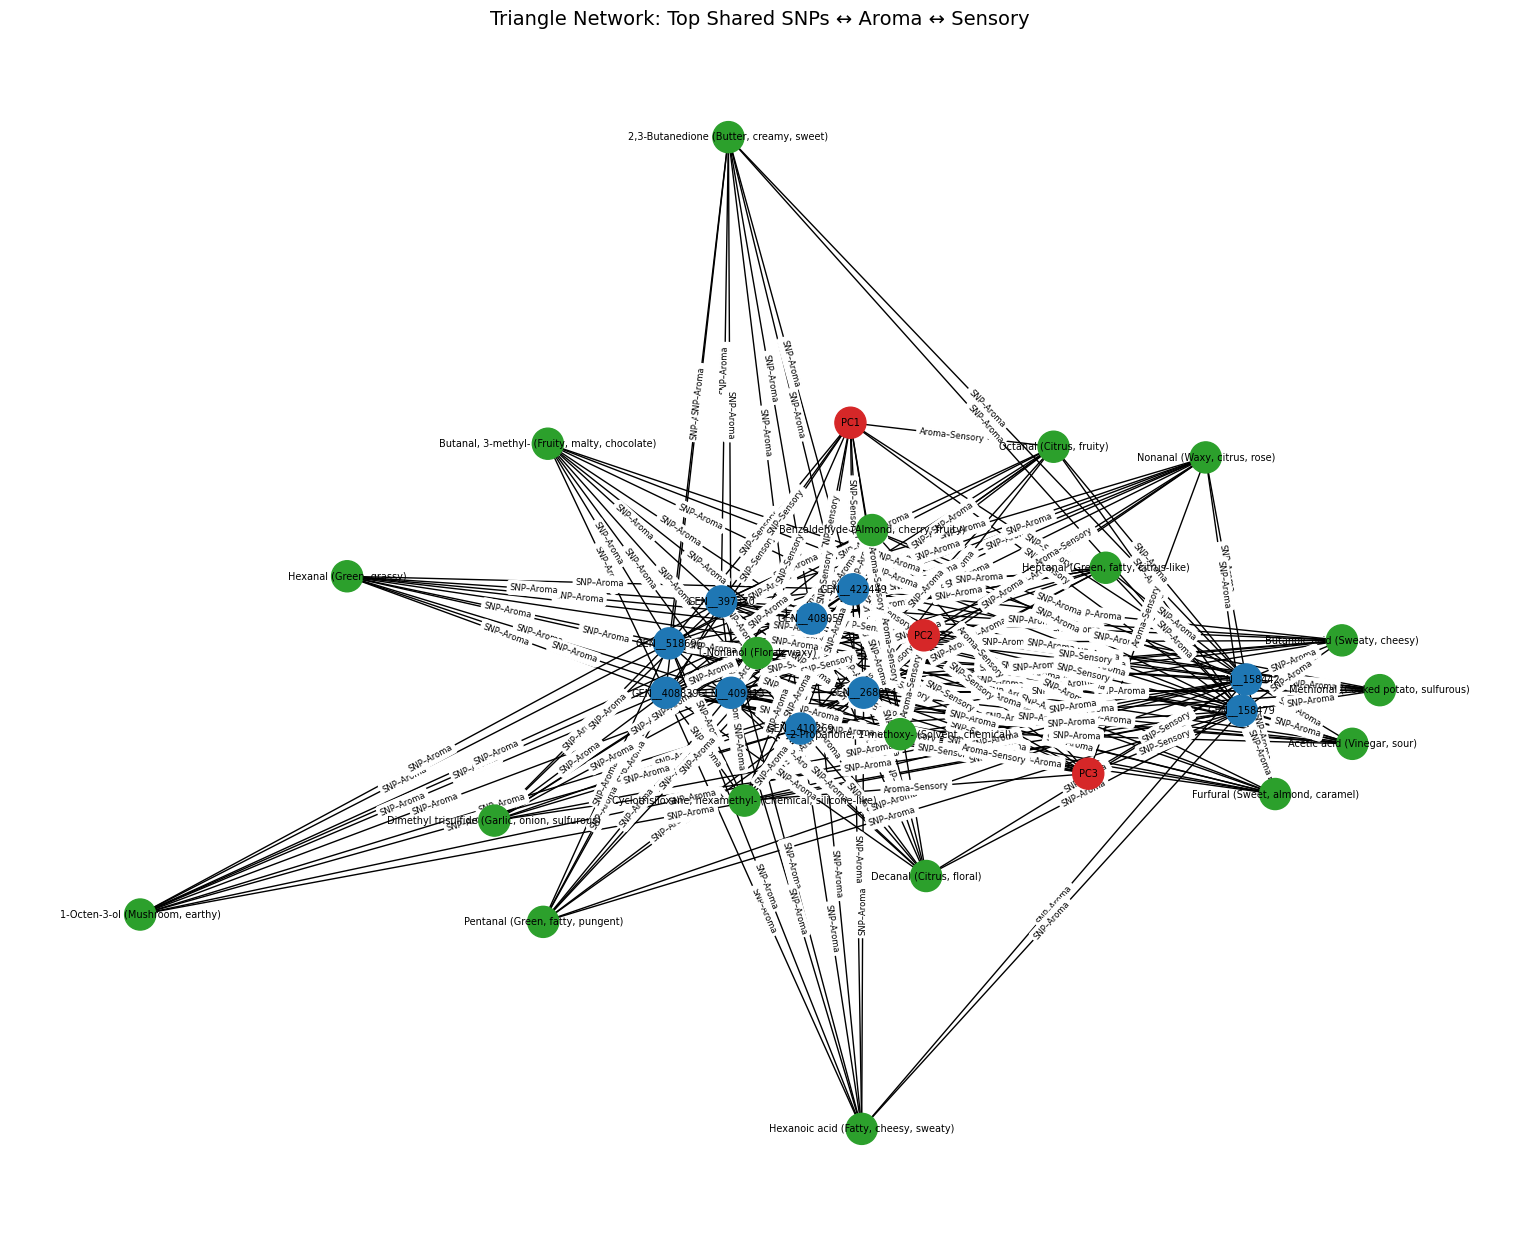

In [31]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------
# Collect SNP–Trait results
# -----------------------
all_snps = []

# From aroma GWAS
for aroma, df in gwas_aroma.items():
    tmp = df.copy()
    tmp["Trait"] = aroma
    tmp["Type"] = "Aroma"
    all_snps.append(tmp)

# From sensory GWAS
for pc, df in gwas_pcs.items():
    tmp = df.copy()
    tmp["Trait"] = pc
    tmp["Type"] = "Sensory"
    all_snps.append(tmp)

all_snps_df = pd.concat(all_snps, ignore_index=True)

# -----------------------
# SNP importance (min p-value across traits)
# -----------------------
snp_scores = (
    all_snps_df.groupby("SNP")["p_value"]
    .min()
    .reset_index()
    .rename(columns={"p_value": "min_p"})
)

# -----------------------
# Shared SNPs = SNPs in both Aroma & Sensory GWAS
# -----------------------
snp_aroma_set = set().union(*[df["SNP"].tolist() for df in gwas_aroma.values()])
snp_sensory_set = set().union(*[df["SNP"].tolist() for df in gwas_pcs.values()])

shared_snps = snp_aroma_set.intersection(snp_sensory_set)

# -----------------------
# Select top shared SNPs
# -----------------------
shared_snps_df = snp_scores[snp_scores["SNP"].isin(shared_snps)]
top_shared_snps = shared_snps_df.nsmallest(10, "min_p")["SNP"].tolist()
print("Top shared SNPs:", len(top_shared_snps))
print(top_shared_snps)

# -----------------------
# Build graph with only top shared SNPs
# -----------------------
G = nx.Graph()
corr_thresh = 0.3

# SNP ↔ Aroma
for aroma, df in gwas_aroma.items():
    sig = df[df["SNP"].isin(top_shared_snps)]
    for _, row in sig.iterrows():
        G.add_node(row["SNP"], group="SNP")
        G.add_node(aroma, group="Aroma")
        G.add_edge(
            row["SNP"], aroma,
            type="SNP–Aroma",
            weight=-np.log10(row["p_value"] + 1e-12)
        )

# SNP ↔ Sensory
for pc, df in gwas_pcs.items():
    sig = df[df["SNP"].isin(top_shared_snps)]
    for _, row in sig.iterrows():
        G.add_node(row["SNP"], group="SNP")
        G.add_node(pc, group="Sensory")
        G.add_edge(
            row["SNP"], pc,
            type="SNP–Sensory",
            weight=-np.log10(row["p_value"] + 1e-12)
        )

# Aroma ↔ Sensory correlations
rows = []
for aroma in [c for c in merged_snp_aroma.columns if not c.startswith("GEN__")]:
    for pc in ["PC1", "PC2", "PC3"]:
        if pc in merged_snp_sensory.columns:
            corr = merged_snp_sensory[pc].corr(merged_snp_aroma[aroma])
            rows.append({"Aroma": aroma, "PC": pc, "Correlation": corr})
aroma_sensory_corr = pd.DataFrame(rows)

for _, row in aroma_sensory_corr.iterrows():
    if abs(row["Correlation"]) > corr_thresh:
        G.add_node(row["Aroma"], group="Aroma")
        G.add_node(row["PC"], group="Sensory")
        G.add_edge(row["Aroma"], row["PC"],
                   type="Aroma–Sensory",
                   weight=abs(row["Correlation"]))

# -----------------------
# Draw network
# -----------------------
color_map = {
    "SNP": "#1f77b4",
    "Aroma": "#2ca02c",
    "Sensory": "#d62728"
}

pos = nx.spring_layout(G, seed=42, k=0.6)
plt.figure(figsize=(15, 12))
node_colors = [color_map[G.nodes[n]["group"]] for n in G.nodes()]
nx.draw(G, pos, with_labels=True, node_color=node_colors, font_size=7, node_size=500)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u, v): d["type"] for u, v, d in G.edges(data=True)},
    font_size=6
)
plt.title("Triangle Network: Top Shared SNPs ↔ Aroma ↔ Sensory", fontsize=14)
plt.show()


PC mapping: {'PC1': 'Bitter Flavour', 'PC2': 'Sweet Flavour', 'PC3': 'Root/ Vegetable Flavour'}


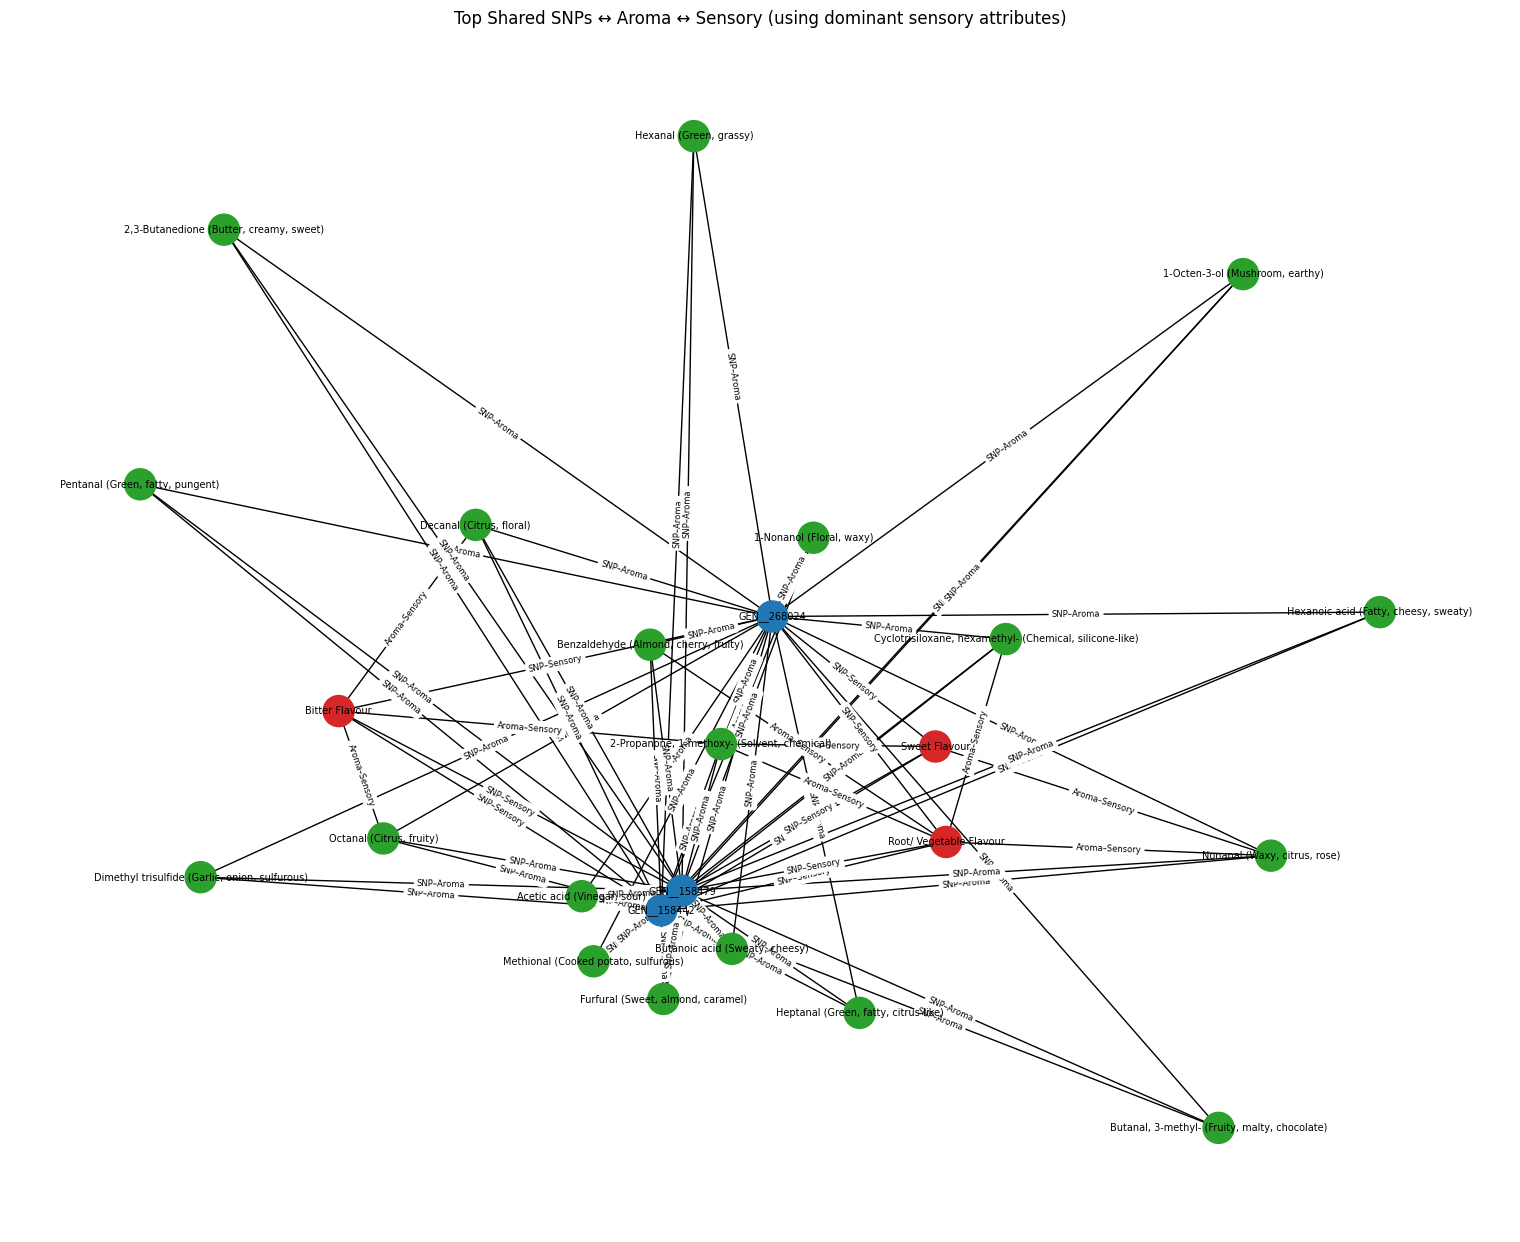

In [32]:
import pandas as pd, numpy as np, networkx as nx, matplotlib.pyplot as plt

# --- 1. Load sensory loadings and map PCs → dominant sensory ---
loadings = pd.read_csv("sensory_pca_loadings.csv", index_col=0)

# pick the attribute with the highest absolute loading per PC
pc_to_label = {}
for pc in loadings.columns:
    top_attr = loadings[pc].abs().sort_values(ascending=False).index[0]
    pc_to_label[pc] = top_attr

print("PC mapping:", pc_to_label)

# --- 2. Collect SNPs from GWAS ---
all_snps = []
for aroma, df in gwas_aroma.items():
    df = df.copy()
    df["Trait"], df["Type"] = aroma, "Aroma"
    all_snps.append(df)

for pc, df in gwas_pcs.items():
    df = df.copy()
    df["Trait"], df["Type"] = pc_to_label.get(pc, pc), "Sensory"  # rename PC → label
    all_snps.append(df)

all_snps_df = pd.concat(all_snps, ignore_index=True)

# --- 3. SNP scores and shared SNPs ---
snp_scores = (
    all_snps_df.groupby("SNP")["p_value"]
    .min()
    .reset_index()
    .rename(columns={"p_value": "min_p"})
)

snp_aroma = set().union(*[df["SNP"] for df in gwas_aroma.values()])
snp_sensory = set().union(*[df["SNP"] for df in gwas_pcs.values()])
shared_snps = snp_aroma & snp_sensory

top_shared = (
    snp_scores[snp_scores["SNP"].isin(shared_snps)]
    .nsmallest(3, "min_p")["SNP"]
    .tolist()
)

# --- 4. Build graph ---
G = nx.Graph()
corr_thresh = 0.3

# SNP ↔ Aroma
for aroma, df in gwas_aroma.items():
    for _, r in df[df["SNP"].isin(top_shared)].iterrows():
        G.add_node(r["SNP"], group="SNP")
        G.add_node(aroma, group="Aroma")
        G.add_edge(
            r["SNP"], aroma,
            type="SNP–Aroma",
            weight=-np.log10(r["p_value"] + 1e-12)
        )

# SNP ↔ Sensory
for pc, df in gwas_pcs.items():
    sensory_label = pc_to_label.get(pc, pc)  # use mapped name
    for _, r in df[df["SNP"].isin(top_shared)].iterrows():
        G.add_node(r["SNP"], group="SNP")
        G.add_node(sensory_label, group="Sensory")
        G.add_edge(
            r["SNP"], sensory_label,
            type="SNP–Sensory",
            weight=-np.log10(r["p_value"] + 1e-12)
        )

# Aroma ↔ Sensory correlation
for _, row in aroma_sensory_corr.iterrows():
    if abs(row["Correlation"]) > corr_thresh:
        sensory_label = pc_to_label.get(row["PC"], row["PC"])
        G.add_node(row["Aroma"], group="Aroma")
        G.add_node(sensory_label, group="Sensory")
        G.add_edge(
            row["Aroma"], sensory_label,
            type="Aroma–Sensory",
            weight=abs(row["Correlation"])
        )

# --- 5. Draw graph ---
colors = {"SNP": "#1f77b4", "Aroma": "#2ca02c", "Sensory": "#d62728"}
pos = nx.spring_layout(G, seed=42, k=0.6)

plt.figure(figsize=(15, 12))
nx.draw(
    G, pos, with_labels=True,
    node_color=[colors[G.nodes[n]["group"]] for n in G.nodes()],
    font_size=7, node_size=500
)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u, v): d["type"] for u, v, d in G.edges(data=True)},
    font_size=6
)
plt.title("Top Shared SNPs ↔ Aroma ↔ Sensory (using dominant sensory attributes)")
plt.show()


In [33]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import pandas as pd

# Assume you already have in memory:
# summary_sensory, merged_snp_aroma, merged_snp_sensory, shared_snps_df

# --- Setup ---
aroma_cols = [c for c in merged_snp_aroma.columns if not c.startswith("GEN__")]
sensory_cols = ["PC1", "PC2", "PC3"]

merged_snp_aroma.index = merged_snp_aroma.index.str.strip().str.upper()
merged_snp_sensory.index = merged_snp_sensory.index.str.strip().str.upper()
summary_sensory["Variety"] = summary_sensory["Variety"].str.strip().str.upper()


varieties = summary_sensory["Variety"].unique()

# --- Dash ---
app = dash.Dash(__name__)
app.layout = html.Div([
    html.H1("Potato Dashboard", style={"textAlign": "center"}),

    dcc.Dropdown(
        id="variety-dropdown",
        options=[{"label": v, "value": v} for v in varieties],
        value=varieties[0],
        style={"width": "50%"}
    ),
    html.Br(),

    html.Div(id="sensory-axis", style={"fontSize": 18, "marginBottom": "20px"}),

    html.Div([
        dcc.Graph(id="aroma-plot", style={"display": "inline-block", "width": "48%"}),
        dcc.Graph(id="sensory-plot", style={"display": "inline-block", "width": "48%"})
    ]),
    html.Br(),

    dcc.Graph(id="gene-plot"),
    html.Br(),

    html.H3("Top 10 Shared SNPs"),
    html.Div(id="snps-table")
])

# --- Callback ---
# --- Callback ---
@app.callback(
    [Output("sensory-axis", "children"),
     Output("aroma-plot", "figure"),
     Output("sensory-plot", "figure"),
     Output("gene-plot", "figure"),
     Output("snps-table", "children")],
    [Input("variety-dropdown", "value")]
)
def update_dashboard(variety):
    v = variety.strip().upper()

    # Sensory axis
    row = summary_sensory.loc[summary_sensory["Variety"] == v]
    axis_text = "No sensory info" if row.empty else f"Dominant axis: {row['Dominant sensory axis'].values[0]}"

    # Aroma profile
    if v in merged_snp_aroma.index:
        aroma_row = merged_snp_aroma.loc[v, aroma_cols]
        aroma_nonzero = aroma_row[aroma_row > 0]
        if not aroma_nonzero.empty:
            aroma_fig = px.bar(x=aroma_nonzero.index, y=aroma_nonzero.values,
                               title=f"Aroma profile {variety}")
        else:
            aroma_fig = px.bar(x=[], y=[], title=f"No nonzero aroma data for {variety}")
    else:
        aroma_fig = px.bar(x=[], y=[], title="No aroma data")

    # Sensory profile
    if v in merged_snp_sensory.index:
        sensory_row = merged_snp_sensory.loc[v, sensory_cols]
        sensory_nonzero = sensory_row[sensory_row != 0]
        if not sensory_nonzero.empty:
            sensory_fig = px.bar(x=sensory_nonzero.index, y=sensory_nonzero.values,
                                 title=f"Sensory PCs {variety}")
        else:
            sensory_fig = px.bar(x=[], y=[], title=f"No nonzero sensory PCs for {variety}")
    else:
        sensory_fig = px.bar(x=[], y=[], title="No sensory data")

    # Genes: filter for variety
    if v in merged_snp_sensory.index:
        snps_present = merged_snp_sensory.loc[v][merged_snp_sensory.loc[v] > 0].index
        snp_subset = shared_snps_df[shared_snps_df["SNP"].isin(snps_present)].head(10)
        gene_fig = px.bar(snp_subset, x="SNP", y="min_p", title=f"Top Shared SNPs {variety}")
    else:
        gene_fig = px.bar(x=[], y=[], title="No SNP data")

    # SNP table
    if not snp_subset.empty:
        table = html.Table([
            html.Thead(html.Tr([html.Th(c) for c in snp_subset.columns])),
            html.Tbody([
                html.Tr([html.Td(snp_subset.iloc[i][c]) for c in snp_subset.columns])
                for i in range(len(snp_subset))
            ])
        ])
    else:
        table = html.Div("No SNPs available")

    return axis_text, aroma_fig, sensory_fig, gene_fig, table



if __name__ == "__main__":
    app.run(debug=True)
